# Step 1: Load USDCUSDT and understand the data

We have two files per crypto pair:
- **Trades file** — individual trades: who bought/sold, how much, at what price, when
- **Market file** — minute-by-minute summary of overall market activity (OHLCV)

Let's load USDCUSDT (the stablecoin pair) and look at what each file contains.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Load the two USDCUSDT files
trades = pd.read_csv('../student-pack/crypto-trades/USDCUSDT_trades.csv', parse_dates=['timestamp'])
market = pd.read_csv('../student-pack/crypto-market/Binance_USDCUSDT_2026_minute.csv', parse_dates=['Date'])

# Let's see what's inside the trades file
print("=== TRADES FILE ===")
print(f"Shape: {trades.shape[0]} rows, {trades.shape[1]} columns\n")
print("Columns:")
for col in trades.columns:
    print(f"  {col:25s} — example: {trades[col].iloc[0]}")

print(f"\n\nFirst 5 trades:")
trades.head()

=== TRADES FILE ===
Shape: 1019 rows, 18 columns

Columns:
  trade_id                  — example: USDCUSDT_00000385
  timestamp                 — example: 2026-01-01 03:26:52.062612
  price                     — example: 1.001244
  quantity                  — example: 0.129535
  side                      — example: BUY
  trader_id                 — example: wallet_USD0027
  manager_id                — example: nan
  exchange                  — example: BINANCE
  order_type                — example: MARKET
  fee_rate                  — example: 0.001379
  settlement_status         — example: SETTLED
  venue_code                — example: VC836
  session_id                — example: d0f867951f6b
  latency_ms                — example: 15
  region_code               — example: US-EAST
  api_version               — example: v2.3
  ip_hash                   — example: a5bb8059
  raw_msg_id                — example: MSG309947489


First 5 trades:


,trade_id,timestamp,price,quantity,side,trader_id,manager_id,exchange,order_type,fee_rate,settlement_status,venue_code,session_id,latency_ms,region_code,api_version,ip_hash,raw_msg_id
0,USDCUSDT_00000385,2026-01-01 03:26:52.062612,1.001244,0.129535,BUY,wallet_USD0027,NaN,BINANCE,MARKET,0.001379,SETTLED,VC836,d0f867951f6b,15,US-EAST,v2.3,a5bb8059,MSG309947489
1,USDCUSDT_00000393,2026-01-01 05:59:31.772006,1.001229,0.150904,BUY,wallet_USD0008,NaN,BINANCE,MARKET,0.000661,SETTLED,VC426,b9302c247619,175,APAC-SOUTH,v2.3,dd958a50,MSG365289704
2,USDCUSDT_00000620,2026-01-01 06:59:00.167963,1.001233,0.270043,SELL,wallet_USD0030,NaN,BINANCE,MARKET,0.000714,SETTLED,VC517,187d1e3662c6,278,APAC-SOUTH,v2.3,47d87c7c,MSG470768516
3,USDCUSDT_00000276,2026-01-01 08:19:49.864895,1.001241,0.664875,SELL,wallet_USD0049,NaN,BINANCE,LIMIT,0.000754,SETTLED,VC486,8a998d14ca48,144,EU-CENTRAL,v3.0,5f50b5e7,MSG779197420
4,USDCUSDT_00000699,2026-01-01 11:17:17.024306,1.001220,0.307025,SELL,wallet_USD0033,NaN,BINANCE,LIMIT,0.001192,SETTLED,VC514,434428ee58e5,459,EU-CENTRAL,v2.3,62026ea5,MSG190666770


# Step 2: What does "normal" look like?

Before we can find suspicious trades, we need to understand what a **normal** USDC trade looks like. USDC is a stablecoin — its price should always be ~$1.00. So let's ask:
- What price do most trades happen at?
- How big are most trades (quantity)?
- How many trades happen per day?
- How many unique wallets are trading?

In [2]:
# --- Price summary ---
print("=== PRICE ===")
print(f"  Min:    ${trades['price'].min():.6f}")
print(f"  Median: ${trades['price'].median():.6f}")
print(f"  Max:    ${trades['price'].max():.6f}")
print(f"  Std:    ${trades['price'].std():.6f}")
print(f"  → Most trades are near $1.00, but the range goes from ${trades['price'].min():.4f} to ${trades['price'].max():.4f}")

# --- Quantity summary ---
print("\n=== QUANTITY (how much USDC per trade) ===")
print(f"  Min:    {trades['quantity'].min():.4f}")
print(f"  Median: {trades['quantity'].median():.4f}")
print(f"  95th %: {trades['quantity'].quantile(0.95):.4f}")
print(f"  99th %: {trades['quantity'].quantile(0.99):.4f}")
print(f"  Max:    {trades['quantity'].max():.4f}")
print(f"  → Typical trade is tiny (~0.2 USDC). But the max is {trades['quantity'].max():.0f} USDC — that's suspicious!")

# --- Wallets ---
print(f"\n=== WALLETS ===")
print(f"  Unique wallets: {trades['trader_id'].nunique()}")
print(f"  Date range: {trades['timestamp'].min().date()} to {trades['timestamp'].max().date()}")

# --- Trades per day ---
trades['date'] = trades['timestamp'].dt.date
daily_counts = trades.groupby('date').size()
print(f"\n=== TRADES PER DAY ===")
print(f"  Average: {daily_counts.mean():.1f} trades/day")
print(f"  Min:     {daily_counts.min()} trades/day")
print(f"  Max:     {daily_counts.max()} trades/day")

=== PRICE ===
  Min:    $0.987836
  Median: $1.000559
  Max:    $1.005697
  Std:    $0.000697
  → Most trades are near $1.00, but the range goes from $0.9878 to $1.0057

=== QUANTITY (how much USDC per trade) ===
  Min:    0.0176
  Median: 0.2220
  95th %: 1.0245
  99th %: 106.6088
  Max:    1052.2840
  → Typical trade is tiny (~0.2 USDC). But the max is 1052 USDC — that's suspicious!

=== WALLETS ===
  Unique wallets: 57
  Date range: 2026-01-01 to 2026-02-28

=== TRADES PER DAY ===
  Average: 17.3 trades/day
  Min:     7 trades/day
  Max:     35 trades/day


# Step 3: Visualize — let the data tell the story

Numbers are useful, but **plots reveal patterns instantly**. We'll make 4 simple plots:
1. Price over time — are there any spikes away from $1.00?
2. Quantity over time (log scale) — do some trades tower over the rest?
3. Trades per day — any unusually busy days?
4. Price distribution — how tight is the cluster around $1.00?

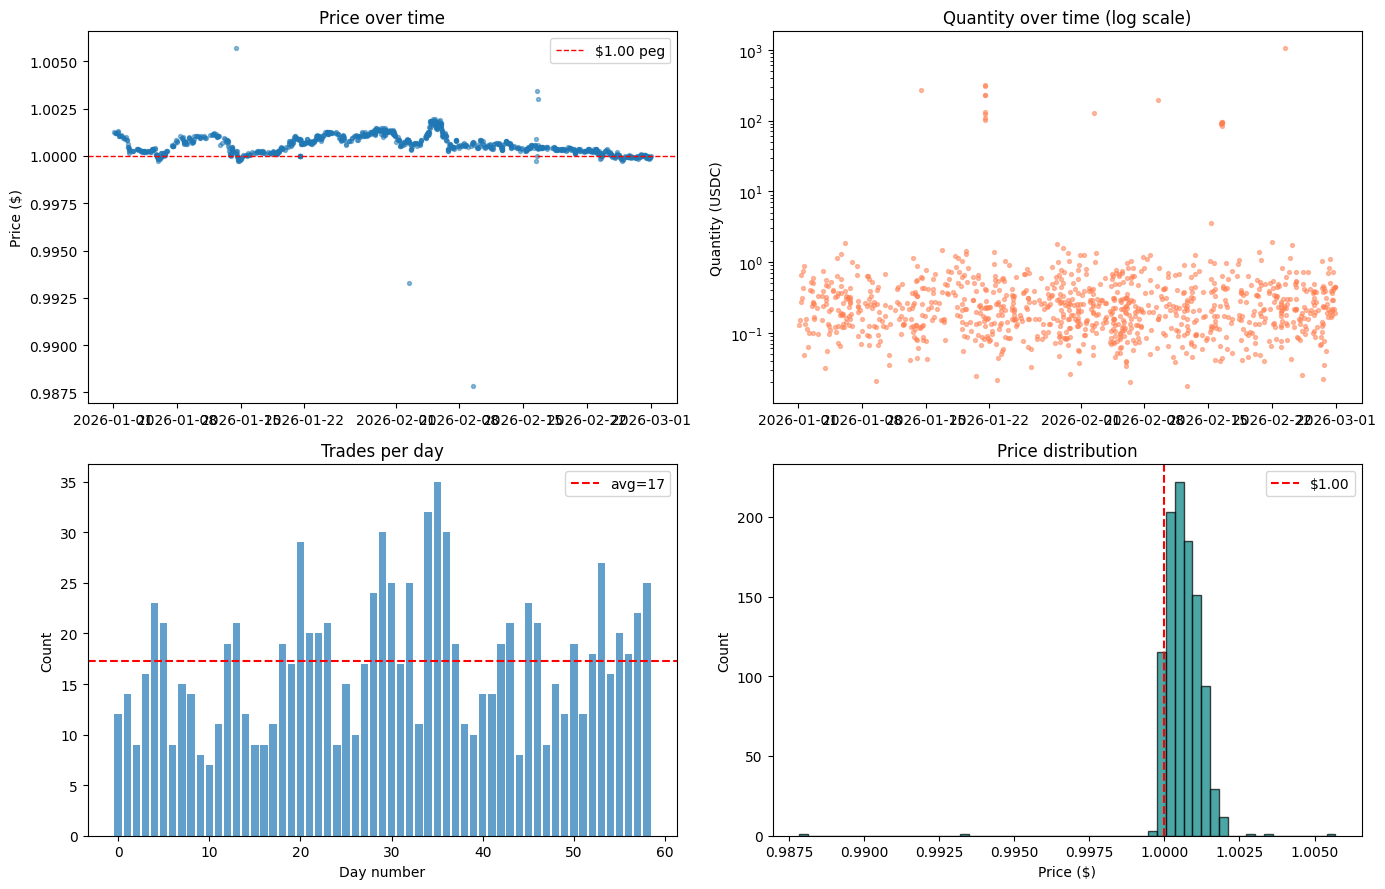

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# 1. Price over time
axes[0,0].scatter(trades['timestamp'], trades['price'], s=8, alpha=0.5)
axes[0,0].axhline(y=1.0, color='red', linestyle='--', linewidth=1, label='$1.00 peg')
axes[0,0].set_title('Price over time')
axes[0,0].set_ylabel('Price ($)')
axes[0,0].legend()

# 2. Quantity over time (log scale so we can see both small and large)
axes[0,1].scatter(trades['timestamp'], trades['quantity'], s=8, alpha=0.5, color='coral')
axes[0,1].set_title('Quantity over time (log scale)')
axes[0,1].set_ylabel('Quantity (USDC)')
axes[0,1].set_yscale('log')

# 3. Trades per day
daily = trades.groupby('date').size()
axes[1,0].bar(range(len(daily)), daily.values, alpha=0.7)
axes[1,0].axhline(y=daily.mean(), color='red', linestyle='--', label=f'avg={daily.mean():.0f}')
axes[1,0].set_title('Trades per day')
axes[1,0].set_ylabel('Count')
axes[1,0].set_xlabel('Day number')
axes[1,0].legend()

# 4. Price distribution (histogram)
axes[1,1].hist(trades['price'], bins=60, edgecolor='black', alpha=0.7, color='teal')
axes[1,1].axvline(x=1.0, color='red', linestyle='--', label='$1.00')
axes[1,1].set_title('Price distribution')
axes[1,1].set_xlabel('Price ($)')
axes[1,1].set_ylabel('Count')
axes[1,1].legend()

plt.tight_layout()
plt.show()

# Step 4: Our first detector — Peg Breaks

**What is a peg break?** USDC is a stablecoin — it's designed to always be worth $1.00. When its price moves away from $1.00 significantly, that's called "breaking the peg."

**Why is it suspicious?** In a surveillance context, someone deliberately traded USDC at a wrong price. Normal market forces keep USDC at $1.00. If someone buys USDC at $1.006 or sells at $0.988, they're either manipulating the price or laundering money.

**How to detect it:** The problem statement tells us directly — flag any trade where `abs(price - 1.0) > 0.005` (more than 0.5% away from $1.00).

Let's find them.

In [4]:
# How far is each trade's price from $1.00?
trades['peg_deviation'] = abs(trades['price'] - 1.0)

# Flag trades where deviation > 0.5%
peg_breaks = trades[trades['peg_deviation'] > 0.005].copy()

print(f"Total trades: {len(trades)}")
print(f"Peg breaks found: {len(peg_breaks)}\n")

# Show each one — with only a few results, we can read every single one
if len(peg_breaks) > 0:
    print(peg_breaks[['trade_id', 'timestamp', 'price', 'peg_deviation', 
                       'quantity', 'side', 'trader_id']].to_string(index=False))

Total trades: 1019
Peg breaks found: 3

         trade_id           timestamp    price  peg_deviation   quantity side trader_id
USDCUSDT_00001001 2026-01-14 11:39:00 1.005697       0.005697 268.848994  BUY trader_01
USDCUSDT_00001010 2026-02-02 10:48:00 0.993304       0.006696 126.012590  BUY trader_04
USDCUSDT_00001011 2026-02-09 11:01:00 0.987836       0.012164 198.014104 SELL trader_05


# Step 5: Understanding Wash Trading

Before we write a detector, let's understand the concept.

**What is wash trading?** A trader (or two traders working together) buy and sell the same asset back and forth. No real ownership changes — they're just faking activity.

**Why do people do it?** To make a token look more popular than it is. Exchanges rank tokens by volume. Higher volume = more visibility = more real buyers show up.

**What does it look like in our data?**
Imagine trader_02 does this on Jan 21:
```
11:39  BUY  130 USDC at $1.00
11:45  SELL 123 USDC at $1.00   ← sold back almost the same amount, 6 min later
11:59  BUY  226 USDC at $1.00
12:03  SELL 229 USDC at $1.00   ← again, buy-sell pair within minutes
```
The wallet ends up with roughly the same amount it started with. No real trade happened — just fake volume.

**For USDCUSDT specifically**, this is called `wash_volume_at_peg` when it happens at exactly $1.00, or `round_trip_wash` when two different wallets do it together.

**How to detect it:** Find pairs of trades that are:
1. Close in time (within ~30 minutes)
2. Opposite sides (one BUY, one SELL)
3. Similar quantities (within 15% of each other)
4. **Abnormally large** — normal trades are ~0.2 USDC, wash trades are 100+ USDC

Let's first just look at what the largest trades in USDCUSDT are, sorted by quantity.

In [5]:
# Let's look at the top 20 largest trades by quantity
# Remember: normal USDC trades are ~0.2 USDC. Anything 50+ is worth investigating.

top20 = trades.nlargest(20, 'quantity')
print("Top 20 USDCUSDT trades by quantity:\n")
print(top20[['trade_id', 'timestamp', 'price', 'quantity', 'side', 'trader_id']].to_string(index=False))

Top 20 USDCUSDT trades by quantity:

         trade_id                  timestamp    price    quantity side      trader_id
USDCUSDT_00001019 2026-02-23 11:00:00.000000 0.999831 1052.284019  BUY         mgr_02
USDCUSDT_00001008 2026-01-21 12:10:55.335573 1.000000  315.455690  BUY      trader_02
USDCUSDT_00001009 2026-01-21 12:18:55.335573 1.000000  311.644842 SELL      trader_03
USDCUSDT_00001001 2026-01-14 11:39:00.000000 1.005697  268.848994  BUY      trader_01
USDCUSDT_00001005 2026-01-21 12:03:22.146995 1.000000  229.582990 SELL      trader_03
USDCUSDT_00001004 2026-01-21 11:59:22.146995 1.000000  226.333675  BUY      trader_02
USDCUSDT_00001011 2026-02-09 11:01:00.000000 0.987836  198.014104 SELL      trader_05
USDCUSDT_00001002 2026-01-21 11:39:58.641616 1.000000  130.593630  BUY      trader_02
USDCUSDT_00001010 2026-02-02 10:48:00.000000 0.993304  126.012590  BUY      trader_04
USDCUSDT_00001003 2026-01-21 11:45:58.641616 1.000000  123.726090 SELL      trader_03
USDCUSDT_00001006

# Step 6: Zoom in — do those 19 large trades pair up?

We saw 19 trades with quantity > 50. Now let's sort them by **time** instead of size. If wash trading is happening, we should see BUY-SELL pairs from the same wallet (or two coordinated wallets) close together in time.

Think of it like this: if you see a 130 USDC BUY at 11:39 and a 123 USDC SELL at 11:45 from related wallets — that's two people passing money back and forth.

In [6]:
# Same 19 trades, but sorted by time so we can see the sequence
large_trades = trades[trades['quantity'] > 50].sort_values('timestamp')

print(f"Large trades (qty > 50), sorted by time:\n")
print(large_trades[['trade_id', 'timestamp', 'price', 'quantity', 'side', 'trader_id']].to_string(index=False))

print("\n\n--- Questions to ask yourself ---")
print("1. Do you see BUY followed by SELL (or vice versa) close in time?")
print("2. Are the quantities in those pairs roughly similar?")
print("3. Which wallets keep appearing?")

Large trades (qty > 50), sorted by time:

         trade_id                  timestamp    price    quantity side trader_id
USDCUSDT_00001001 2026-01-14 11:39:00.000000 1.005697  268.848994  BUY trader_01
USDCUSDT_00001002 2026-01-21 11:39:58.641616 1.000000  130.593630  BUY trader_02
USDCUSDT_00001003 2026-01-21 11:45:58.641616 1.000000  123.726090 SELL trader_03
USDCUSDT_00001004 2026-01-21 11:59:22.146995 1.000000  226.333675  BUY trader_02
USDCUSDT_00001005 2026-01-21 12:03:22.146995 1.000000  229.582990 SELL trader_03
USDCUSDT_00001006 2026-01-21 12:03:45.659680 1.000000  107.943094  BUY trader_02
USDCUSDT_00001007 2026-01-21 12:10:45.659680 1.000000  100.530280 SELL trader_03
USDCUSDT_00001008 2026-01-21 12:10:55.335573 1.000000  315.455690  BUY trader_02
USDCUSDT_00001009 2026-01-21 12:18:55.335573 1.000000  311.644842 SELL trader_03
USDCUSDT_00001010 2026-02-02 10:48:00.000000 0.993304  126.012590  BUY trader_04
USDCUSDT_00001011 2026-02-09 11:01:00.000000 0.987836  198.014104 S

# Step 7: Build the wash trading detector

Now that we've seen the pattern visually, let's automate the detection.

**The logic:** Loop through the large trades. For each one, check if there's another large trade nearby in time that:
- Is on the **opposite side** (BUY vs SELL)
- Has a **similar quantity** (within 15%)
- Happened within **30 minutes**

If we find such a pair, those trades are likely wash trading.

In [7]:
# Start with the large trades sorted by time
large = trades[trades['quantity'] > 50].sort_values('timestamp').reset_index(drop=True)

wash_pairs = []

for i in range(len(large)):
    for j in range(i + 1, len(large)):
        t1 = large.iloc[i]
        t2 = large.iloc[j]
        
        # Time difference in minutes
        dt = (t2['timestamp'] - t1['timestamp']).total_seconds() / 60
        if dt > 30:
            break  # too far apart, stop checking
        
        # Must be opposite sides
        if t1['side'] == t2['side']:
            continue
        
        # Quantity must be similar (within 15%)
        qty_diff = abs(t1['quantity'] - t2['quantity']) / max(t1['quantity'], t2['quantity'])
        if qty_diff > 0.15:
            continue
        
        # Found a pair!
        wash_pairs.append({
            'trade_1': t1['trade_id'],
            'trade_2': t2['trade_id'],
            'wallet_1': t1['trader_id'],
            'wallet_2': t2['trader_id'],
            'side_1': t1['side'],
            'side_2': t2['side'],
            'qty_1': round(t1['quantity'], 2),
            'qty_2': round(t2['quantity'], 2),
            'time_gap_min': round(dt, 1),
            'same_wallet': t1['trader_id'] == t2['trader_id']
        })

print(f"Wash trading pairs found: {len(wash_pairs)}\n")
for p in wash_pairs:
    wallet_info = "SAME wallet" if p['same_wallet'] else f"DIFFERENT wallets ({p['wallet_1']} ↔ {p['wallet_2']})"
    print(f"  {p['trade_1']} {p['side_1']} {p['qty_1']} USDC")
    print(f"  {p['trade_2']} {p['side_2']} {p['qty_2']} USDC")
    print(f"  → {p['time_gap_min']} min apart | {wallet_info}")
    print()

Wash trading pairs found: 5

  USDCUSDT_00001002 BUY 130.59 USDC
  USDCUSDT_00001003 SELL 123.73 USDC
  → 6.0 min apart | DIFFERENT wallets (trader_02 ↔ trader_03)

  USDCUSDT_00001003 SELL 123.73 USDC
  USDCUSDT_00001006 BUY 107.94 USDC
  → 17.8 min apart | DIFFERENT wallets (trader_03 ↔ trader_02)

  USDCUSDT_00001004 BUY 226.33 USDC
  USDCUSDT_00001005 SELL 229.58 USDC
  → 4.0 min apart | DIFFERENT wallets (trader_02 ↔ trader_03)

  USDCUSDT_00001006 BUY 107.94 USDC
  USDCUSDT_00001007 SELL 100.53 USDC
  → 7.0 min apart | DIFFERENT wallets (trader_02 ↔ trader_03)

  USDCUSDT_00001008 BUY 315.46 USDC
  USDCUSDT_00001009 SELL 311.64 USDC
  → 8.0 min apart | DIFFERENT wallets (trader_02 ↔ trader_03)



# Step 8: Understanding Structuring (Smurfing)

Now let's learn the next violation type.

**What is structuring?** Imagine you want to move $100,000 through a system, but transactions above $10,000 get flagged and reported to authorities. So instead, you break it into ten $9,900 transactions. That's structuring — also called "smurfing."

**What it looks like in data:**
- One wallet makes **many trades** in a short window (a few hours)
- All trades are **suspiciously similar in size** (e.g., all ~90 USDC)
- The sizes have very low variation — measured by **coefficient of variation (CV)**

**CV = standard deviation / mean**
- CV < 0.10 means quantities are nearly identical → very suspicious
- CV > 0.50 means quantities are varied → normal trading

Let's scan all wallets in USDCUSDT for this pattern: wallets with 3+ trades, low CV, happening in a short burst.

In [8]:
# For each wallet, compute: how many trades, average quantity, CV, time span
wallet_stats = trades.groupby('trader_id').agg(
    n_trades=('trade_id', 'count'),
    qty_mean=('quantity', 'mean'),
    qty_std=('quantity', 'std'),
    time_first=('timestamp', 'min'),
    time_last=('timestamp', 'max')
).reset_index()

# Coefficient of variation
wallet_stats['cv'] = wallet_stats['qty_std'] / (wallet_stats['qty_mean'] + 1e-10)

# Time span in hours
wallet_stats['span_hours'] = (wallet_stats['time_last'] - wallet_stats['time_first']).dt.total_seconds() / 3600

# Filter: 3+ trades, low CV, short time span, and quantity well above normal
median_qty = trades['quantity'].median()
structuring = wallet_stats[
    (wallet_stats['n_trades'] >= 3) &
    (wallet_stats['cv'] < 0.10) &
    (wallet_stats['span_hours'] < 24) &
    (wallet_stats['qty_mean'] > median_qty * 5)  # much bigger than typical trades
].sort_values('cv')

print(f"Normal trade size (median): {median_qty:.4f} USDC")
print(f"Wallets with structuring pattern: {len(structuring)}\n")

if len(structuring) > 0:
    print(structuring[['trader_id', 'n_trades', 'qty_mean', 'cv', 'span_hours']].to_string(index=False))
    
    # Show the actual trades for each flagged wallet
    for wallet in structuring['trader_id']:
        wt = trades[trades['trader_id'] == wallet].sort_values('timestamp')
        print(f"\n--- Trades by {wallet} ---")
        print(wt[['trade_id', 'timestamp', 'price', 'quantity', 'side']].to_string(index=False))
else:
    print("No structuring found with these criteria.")

Normal trade size (median): 0.2220 USDC
Wallets with structuring pattern: 1

trader_id  n_trades  qty_mean       cv  span_hours
trader_06         7 90.884956 0.046717    2.910249

--- Trades by trader_06 ---
         trade_id                  timestamp    price  quantity side
USDCUSDT_00001012 2026-02-16 10:56:46.744985 1.000910 87.968893  BUY
USDCUSDT_00001013 2026-02-16 11:02:31.633125 0.999719 93.699429  BUY
USDCUSDT_00001014 2026-02-16 11:22:29.311283 1.000021 94.182438  BUY
USDCUSDT_00001015 2026-02-16 11:36:36.057789 1.000470 94.703603  BUY
USDCUSDT_00001016 2026-02-16 12:30:26.344056 1.003430 82.783322  BUY
USDCUSDT_00001017 2026-02-16 13:50:26.109555 1.003010 91.256560  BUY
USDCUSDT_00001018 2026-02-16 13:51:23.640700 1.000562 91.600449  BUY


# Step 9: Take stock — what have we found in USDCUSDT so far?

Before moving on, let's collect everything we've found and count how many of our 50 trade_id budget we're using. We need to be disciplined about this.

We found 3 types of violations:
1. **Peg breaks** (Step 4) — trades at prices far from $1.00
2. **Round-trip wash** (Step 7) — paired BUY-SELL between two wallets
3. **Structuring** (Step 8) — uniform-size trades in a burst

Let's gather the unique trade_ids from all three detectors.

In [9]:
# Collect all flagged trade_ids from our three detectors

usdcusdt_flags = []

# 1. Peg breaks
for _, row in peg_breaks.iterrows():
    usdcusdt_flags.append({
        'symbol': 'USDCUSDT',
        'date': str(row['date']),
        'trade_id': row['trade_id'],
        'violation_type': 'peg_break',
        'remarks': f"Price ${row['price']:.6f} deviates {row['peg_deviation']*100:.2f}% from $1.00 peg"
    })

# 2. Wash trading pairs (collect unique trade_ids from all pairs)
wash_trade_ids = set()
for p in wash_pairs:
    wash_trade_ids.add(p['trade_1'])
    wash_trade_ids.add(p['trade_2'])

for tid in wash_trade_ids:
    row = trades[trades['trade_id'] == tid].iloc[0]
    usdcusdt_flags.append({
        'symbol': 'USDCUSDT',
        'date': str(row['date']),
        'trade_id': tid,
        'violation_type': 'round_trip_wash',
        'remarks': f"BUY-SELL pair with matched qty within minutes at peg price — two wallets trading back and forth"
    })

# 3. Structuring
if len(structuring) > 0:
    for wallet in structuring['trader_id']:
        wt = trades[trades['trader_id'] == wallet]
        cv_val = structuring[structuring['trader_id'] == wallet]['cv'].values[0]
        n = len(wt)
        for _, row in wt.iterrows():
            usdcusdt_flags.append({
                'symbol': 'USDCUSDT',
                'date': str(row['date']),
                'trade_id': row['trade_id'],
                'violation_type': 'aml_structuring',
                'remarks': f"Wallet {wallet}: {n} trades with near-identical quantities (CV={cv_val:.3f}) in a few hours — smurfing"
            })

# Deduplicate (a trade might appear in both peg_break and wash)
flags_df = pd.DataFrame(usdcusdt_flags).drop_duplicates(subset='trade_id', keep='first')

print(f"=== USDCUSDT Summary ===")
print(f"Unique trade_ids flagged: {len(flags_df)}")
print(f"Budget used: {len(flags_df)} / 50\n")
print("By violation type:")
print(flags_df['violation_type'].value_counts().to_string())
print(f"\nAll flagged trades:")
print(flags_df[['trade_id', 'violation_type', 'remarks']].to_string(index=False))

=== USDCUSDT Summary ===
Unique trade_ids flagged: 18
Budget used: 18 / 50

By violation type:
violation_type
round_trip_wash    8
aml_structuring    7
peg_break          3

All flagged trades:
         trade_id  violation_type                                                                                         remarks
USDCUSDT_00001001       peg_break                                                   Price $1.005697 deviates 0.57% from $1.00 peg
USDCUSDT_00001010       peg_break                                                   Price $0.993304 deviates 0.67% from $1.00 peg
USDCUSDT_00001011       peg_break                                                   Price $0.987836 deviates 1.22% from $1.00 peg
USDCUSDT_00001004 round_trip_wash BUY-SELL pair with matched qty within minutes at peg price — two wallets trading back and forth
USDCUSDT_00001005 round_trip_wash BUY-SELL pair with matched qty within minutes at peg price — two wallets trading back and forth
USDCUSDT_00001007 round_tr

In [10]:
# Save USDCUSDT flags as our initial submission.csv
flags_df.to_csv('submission.csv', index=False)
print(f"Saved {len(flags_df)} flags to submission.csv")
print("We'll append more flags as we analyze each pair.")

Saved 18 flags to submission.csv
We'll append more flags as we analyze each pair.


# Step 10: Load BATUSDT and understand it

**BAT (Basic Attention Token)** is very different from USDC:
- USDC is a stablecoin at $1.00 — BAT is a real token with a fluctuating price (~$0.10-0.23)
- USDC had 1,019 trades — BAT has the **fewest trades** of all 8 pairs
- In a low-liquidity market, any unusual activity stands out dramatically

The problem statement tells us: *"compute hourly volume baseline per day. Flag hours with volume >5x median. Look at the trades in those hours."*

Let's start by loading the data and getting a feel for it — same as we did for USDCUSDT.

In [11]:
# Load BATUSDT
bat_trades = pd.read_csv('../student-pack/crypto-trades/BATUSDT_trades.csv', parse_dates=['timestamp'])
bat_market = pd.read_csv('../student-pack/crypto-market/Binance_BATUSDT_2026_minute.csv', parse_dates=['Date'])

bat_trades['date'] = bat_trades['timestamp'].dt.date

print("=== BATUSDT TRADES ===")
print(f"Total trades: {len(bat_trades)}")
print(f"Date range: {bat_trades['timestamp'].min().date()} to {bat_trades['timestamp'].max().date()}")
print(f"Unique wallets: {bat_trades['trader_id'].nunique()}")

print(f"\n=== PRICE ===")
print(f"  Min:    ${bat_trades['price'].min():.4f}")
print(f"  Median: ${bat_trades['price'].median():.4f}")
print(f"  Max:    ${bat_trades['price'].max():.4f}")

print(f"\n=== QUANTITY ===")
print(f"  Min:    {bat_trades['quantity'].min():.4f}")
print(f"  Median: {bat_trades['quantity'].median():.4f}")
print(f"  95th %: {bat_trades['quantity'].quantile(0.95):.4f}")
print(f"  99th %: {bat_trades['quantity'].quantile(0.99):.4f}")
print(f"  Max:    {bat_trades['quantity'].max():.2f}")
print(f"  → Median is {bat_trades['quantity'].median():.2f} BAT, but max is {bat_trades['quantity'].max():.0f} BAT!")

print(f"\n=== TRADES PER DAY ===")
daily = bat_trades.groupby('date').size()
print(f"  Average: {daily.mean():.1f} trades/day")
print(f"  → That's just {daily.mean():.0f} trades a day. Very quiet market.")

=== BATUSDT TRADES ===
Total trades: 535
Date range: 2026-01-01 to 2026-02-28
Unique wallets: 34

=== PRICE ===
  Min:    $0.0980
  Median: $0.1880
  Max:    $0.2351

=== QUANTITY ===
  Min:    0.0015
  Median: 0.2119
  95th %: 4.9569
  99th %: 94.3861
  Max:    426.83
  → Median is 0.21 BAT, but max is 427 BAT!

=== TRADES PER DAY ===
  Average: 9.9 trades/day
  → That's just 10 trades a day. Very quiet market.


# Step 11: Visualize BATUSDT — spot the anomalies

Same 4 plots as USDCUSDT, but now for a volatile low-liquidity token. The key difference: BAT's price actually moves, so we're looking for **quantity outliers** and **unusual time clusters** rather than price deviations from a peg.

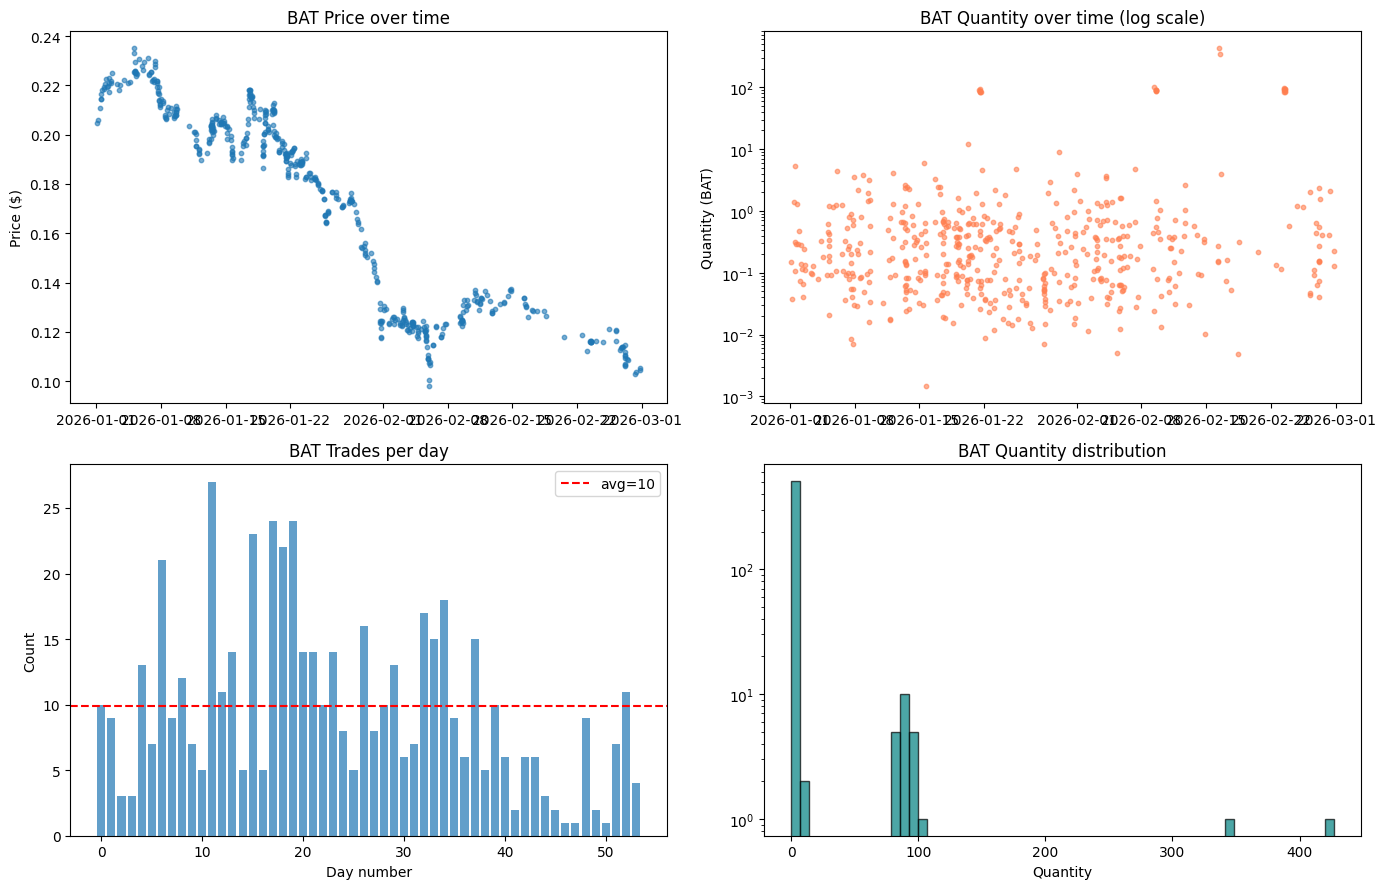

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# 1. Price over time
axes[0,0].scatter(bat_trades['timestamp'], bat_trades['price'], s=10, alpha=0.6)
axes[0,0].set_title('BAT Price over time')
axes[0,0].set_ylabel('Price ($)')

# 2. Quantity over time (log scale)
axes[0,1].scatter(bat_trades['timestamp'], bat_trades['quantity'], s=10, alpha=0.6, color='coral')
axes[0,1].set_title('BAT Quantity over time (log scale)')
axes[0,1].set_ylabel('Quantity (BAT)')
axes[0,1].set_yscale('log')

# 3. Trades per day
daily = bat_trades.groupby('date').size()
axes[1,0].bar(range(len(daily)), daily.values, alpha=0.7)
axes[1,0].axhline(y=daily.mean(), color='red', linestyle='--', label=f'avg={daily.mean():.0f}')
axes[1,0].set_title('BAT Trades per day')
axes[1,0].set_ylabel('Count')
axes[1,0].set_xlabel('Day number')
axes[1,0].legend()

# 4. Quantity distribution (log scale on x-axis to see the spread)
axes[1,1].hist(bat_trades['quantity'], bins=60, edgecolor='black', alpha=0.7, color='teal')
axes[1,1].set_title('BAT Quantity distribution')
axes[1,1].set_xlabel('Quantity')
axes[1,1].set_yscale('log')

plt.tight_layout()
plt.show()

# Step 12: The Hourly Volume Baseline approach

This is the approach the problem statement specifically recommends for BATUSDT.

**The idea:** The **market data** (OHLCV) tells us the total volume traded every minute across the entire exchange — not just our trades file, but ALL trades. If a particular hour has volume 5x higher than the typical hour, something unusual is happening.

We then go look at **which trades from our file** happened during that unusual hour.

**Why use market data instead of just our trades?** Our trades file is a sample. The market OHLCV captures everything. A volume spike in the market data means the overall market was abnormally active — and our suspicious trades likely caused that spike.

In [13]:
# Compute hourly volume from market data (Jan-Feb only)
bat_mkt = bat_market.sort_values('Date').set_index('Date')
bat_mkt_jf = bat_mkt.loc[:'2026-02-28']

# Resample: sum up Volume USDT for each hour
hourly_vol = bat_mkt_jf['Volume USDT'].resample('1h').sum()

# What's a "normal" hour?
median_vol = hourly_vol.median()
threshold = median_vol * 5

print(f"Hourly volume stats:")
print(f"  Median hour: {median_vol:,.0f} USDT")
print(f"  5x threshold: {threshold:,.0f} USDT")
print(f"  Max hour:     {hourly_vol.max():,.0f} USDT")

# Find hours above the threshold
hot_hours = hourly_vol[hourly_vol > threshold]
print(f"\nHours with volume > 5x median: {len(hot_hours)}")
print(f"(That's {len(hot_hours)} suspicious hours out of {len(hourly_vol)} total hours)")

Hourly volume stats:
  Median hour: 37,028 USDT
  5x threshold: 185,141 USDT
  Max hour:     1,034,907 USDT

Hours with volume > 5x median: 75
(That's 75 suspicious hours out of 1416 total hours)


# Step 13: Look inside the hot hours — which trades are there?

75 hot hours is a lot. We can't manually inspect all of them. But here's the key insight: **most of those 75 hours are just naturally busy market hours.** The real violations will stand out because:

- The trades in those hours will have **abnormally large quantities** (compared to normal BAT trades)
- They might come from wallets we don't normally see

So let's filter: among all trades that happened during hot hours, show only those with quantity **above the 95th percentile** for BAT. This gives us the intersection of "unusual time" AND "unusual size."

In [14]:
# Find trades that occurred during hot hours AND have large quantity
bat_jf = bat_trades[bat_trades['timestamp'] < '2026-03-01'].copy()
qty_95 = bat_jf['quantity'].quantile(0.95)

print(f"95th percentile quantity: {qty_95:.2f} BAT")
print(f"(Only ~5% of trades are larger than this)\n")

# For each trade, check if it falls in a hot hour
bat_jf['hour_start'] = bat_jf['timestamp'].dt.floor('h')
bat_jf['in_hot_hour'] = bat_jf['hour_start'].isin(hot_hours.index)

# Trades that are BOTH in a hot hour AND unusually large
suspicious = bat_jf[(bat_jf['in_hot_hour']) & (bat_jf['quantity'] > qty_95)].sort_values('timestamp')

print(f"Trades in hot hours with qty > 95th percentile: {len(suspicious)}\n")
print(suspicious[['trade_id', 'timestamp', 'price', 'quantity', 'side', 'trader_id']].to_string(index=False))

95th percentile quantity: 4.96 BAT
(Only ~5% of trades are larger than this)

Trades in hot hours with qty > 95th percentile: 3

        trade_id                  timestamp    price  quantity side      trader_id
BATUSDT_00000448 2026-01-01 12:30:45.762601 0.214627  5.280726 SELL wallet_BAT0006
BATUSDT_00000384 2026-01-20 06:23:53.749263 0.201661 12.085300  BUY wallet_BAT0017
BATUSDT_00000525 2026-02-09 14:07:30.164246 0.124671 90.894651  BUY      trader_10


# Step 14: Don't stop at hot hours — check ALL large trades

The hourly volume approach found 3 trades. But it only catches trades that happen during market-wide volume spikes. What if a violation trade is large but happens during a **quiet** hour? It wouldn't spike the overall market volume enough to hit 5x median.

So let's also look at it from the other direction: **all trades above the 95th percentile**, regardless of which hour they're in. This catches anything we might have missed.

In [16]:
# All BAT trades (Jan-Feb) above 95th percentile, sorted by quantity
all_large_bat = bat_jf[bat_jf['quantity'] > qty_95].sort_values('quantity', ascending=False)

print(f"ALL large BAT trades (qty > {qty_95:.2f}), sorted by size:\n")
print(all_large_bat[['trade_id', 'timestamp', 'price', 'quantity', 'side', 'trader_id']].to_string(index=False))

print(f"\nTotal: {len(all_large_bat)} large trades")
print(f"(The 3 we found in hot hours are a subset of these)")

ALL large BAT trades (qty > 4.96), sorted by size:

        trade_id                  timestamp    price   quantity side      trader_id
BATUSDT_00000526 2026-02-16 10:32:00.000000 0.130326 426.828654  BUY      trader_09
BATUSDT_00000527 2026-02-16 10:58:00.000000 0.130215 344.357452  BUY      trader_10
BATUSDT_00000520 2026-02-09 10:05:00.000000 0.124136 100.000000  BUY      trader_10
BATUSDT_00000528 2026-02-23 10:10:10.120908 0.116325  96.582923  BUY      trader_09
BATUSDT_00000531 2026-02-23 11:51:01.626731 0.115987  94.865523  BUY      trader_09
BATUSDT_00000530 2026-02-23 11:34:58.143280 0.116029  94.751405  BUY      trader_09
BATUSDT_00000529 2026-02-23 11:23:58.587047 0.116446  93.676919  BUY      trader_09
BATUSDT_00000505 2026-01-21 12:53:47.814604 0.192180  93.543357  BUY      trader_08
BATUSDT_00000533 2026-02-23 11:10:05.229428 0.115965  91.089680  BUY      trader_10
BATUSDT_00000525 2026-02-09 14:07:30.164246 0.124671  90.894651  BUY      trader_10
BATUSDT_00000524 2026-02

# Step 15: Which violations apply to BATUSDT?

We have 27 large trades. But not all large trades are violations — some could just be big legitimate trades. We need to check if these trades show **violation behavior patterns**.

For BATUSDT (low liquidity, real price movement), the relevant violations are:
- **`aml_structuring`** — same wallet, many trades of uniform size in a burst
- **`ramping`** — same wallet, sequential trades at rising prices
- **`coordinated_pump`** — multiple wallets buying simultaneously

Let's group these 27 trades by wallet to see which wallets are most active.

In [17]:
# Group the 27 large trades by wallet
print("=== Large trades grouped by wallet ===\n")

for wallet in all_large_bat['trader_id'].unique():
    wt = all_large_bat[all_large_bat['trader_id'] == wallet].sort_values('timestamp')
    n = len(wt)
    
    # Calculate CV (are the quantities uniform?)
    cv = wt['quantity'].std() / wt['quantity'].mean() if n > 1 else 0
    
    # Time span
    if n > 1:
        span_h = (wt['timestamp'].max() - wt['timestamp'].min()).total_seconds() / 3600
    else:
        span_h = 0
    
    print(f"── {wallet}: {n} trades, avg qty={wt['quantity'].mean():.2f}, CV={cv:.3f}, span={span_h:.1f}h ──")
    print(wt[['trade_id', 'timestamp', 'price', 'quantity', 'side']].to_string(index=False))
    
    # Flag interesting patterns
    if n >= 3 and cv < 0.10:
        print(f"  ⚠ STRUCTURING PATTERN: {n} trades with very uniform quantities")
    if n >= 3 and all(wt['side'] == 'BUY'):
        print(f"  ⚠ ALL BUYS: could be coordinated pump or ramping")
    print()

=== Large trades grouped by wallet ===

── trader_09: 5 trades, avg qty=161.34, CV=0.920, span=169.3h ──
        trade_id                  timestamp    price   quantity side
BATUSDT_00000526 2026-02-16 10:32:00.000000 0.130326 426.828654  BUY
BATUSDT_00000528 2026-02-23 10:10:10.120908 0.116325  96.582923  BUY
BATUSDT_00000529 2026-02-23 11:23:58.587047 0.116446  93.676919  BUY
BATUSDT_00000530 2026-02-23 11:34:58.143280 0.116029  94.751405  BUY
BATUSDT_00000531 2026-02-23 11:51:01.626731 0.115987  94.865523  BUY
  ⚠ ALL BUYS: could be coordinated pump or ramping

── trader_10: 11 trades, avg qty=112.13, CV=0.688, span=337.9h ──
        trade_id                  timestamp    price   quantity side
BATUSDT_00000520 2026-02-09 10:05:00.000000 0.124136 100.000000  BUY
BATUSDT_00000521 2026-02-09 12:55:54.024745 0.124268  89.515501  BUY
BATUSDT_00000522 2026-02-09 13:09:44.329165 0.124308  85.890039  BUY
BATUSDT_00000523 2026-02-09 13:44:47.095565 0.124271  87.488397  BUY
BATUSDT_00000524 2

# Step 16: Take stock — what have we found in BATUSDT?

Let's collect our BATUSDT findings. From the wallet analysis, we should have:
- Wallets with **structuring** patterns (uniform quantities, low CV)
- Wallets with **all-BUY** patterns (could be coordinated pump)

We'll only flag wallets that have a **clear behavioral pattern** — not just "large trade from an unknown wallet." Remember: 32 budget remaining, and we still have 6 more pairs to analyze.

In [18]:
# Collect BATUSDT flags — only wallets with clear patterns
batusdt_flags = []

for wallet in all_large_bat['trader_id'].unique():
    wt = all_large_bat[all_large_bat['trader_id'] == wallet].sort_values('timestamp')
    n = len(wt)
    if n < 3:
        continue  # skip wallets with too few trades to confirm a pattern
    
    cv = wt['quantity'].std() / wt['quantity'].mean()
    span_h = (wt['timestamp'].max() - wt['timestamp'].min()).total_seconds() / 3600
    all_buys = all(wt['side'] == 'BUY')
    
    # Decide violation type based on behavior
    if cv < 0.10 and span_h < 24:
        vtype = 'aml_structuring'
        remark = f"Wallet {wallet}: {n} trades with uniform quantities (CV={cv:.3f}) within {span_h:.1f}h — smurfing"
    elif all_buys and span_h < 24:
        vtype = 'coordinated_pump'
        remark = f"Wallet {wallet}: {n} consecutive BUY trades totaling {wt['quantity'].sum():.0f} BAT within {span_h:.1f}h — coordinated buying"
    else:
        continue  # no clear pattern, skip
    
    for _, row in wt.iterrows():
        batusdt_flags.append({
            'symbol': 'BATUSDT',
            'date': str(row['date']),
            'trade_id': row['trade_id'],
            'violation_type': vtype,
            'remarks': remark
        })

bat_flags_df = pd.DataFrame(batusdt_flags)

print(f"=== BATUSDT Summary ===")
print(f"Unique trade_ids flagged: {len(bat_flags_df)}")
print(f"\nBy violation type:")
if len(bat_flags_df) > 0:
    print(bat_flags_df['violation_type'].value_counts().to_string())
    print(f"\nAll flagged trades:")
    print(bat_flags_df[['trade_id', 'violation_type', 'remarks']].to_string(index=False))

# Running total
existing = pd.read_csv('submission.csv')
total_so_far = len(existing) + len(bat_flags_df)
print(f"\n=== Budget ===")
print(f"USDCUSDT: {len(existing)} flags")
print(f"BATUSDT:  {len(bat_flags_df)} flags")
print(f"Total:    {total_so_far} / 50 used")

=== BATUSDT Summary ===
Unique trade_ids flagged: 7

By violation type:
violation_type
aml_structuring    7

All flagged trades:
        trade_id  violation_type                                                                              remarks
BATUSDT_00000503 aml_structuring Wallet trader_08: 7 trades with uniform quantities (CV=0.047) within 4.5h — smurfing
BATUSDT_00000504 aml_structuring Wallet trader_08: 7 trades with uniform quantities (CV=0.047) within 4.5h — smurfing
BATUSDT_00000505 aml_structuring Wallet trader_08: 7 trades with uniform quantities (CV=0.047) within 4.5h — smurfing
BATUSDT_00000506 aml_structuring Wallet trader_08: 7 trades with uniform quantities (CV=0.047) within 4.5h — smurfing
BATUSDT_00000507 aml_structuring Wallet trader_08: 7 trades with uniform quantities (CV=0.047) within 4.5h — smurfing
BATUSDT_00000508 aml_structuring Wallet trader_08: 7 trades with uniform quantities (CV=0.047) within 4.5h — smurfing
BATUSDT_00000509 aml_structuring Wallet trade

In [19]:
# Save BATUSDT flags — append to existing submission
combined = pd.concat([existing, bat_flags_df], ignore_index=True)
combined.to_csv('submission.csv', index=False)
print(f"Saved! submission.csv now has {len(combined)} flags (USDCUSDT + BATUSDT)")
print(f"Budget remaining: {50 - len(combined)}")

Saved! submission.csv now has 25 flags (USDCUSDT + BATUSDT)
Budget remaining: 25


# Step 17: Load DOGEUSDT and explore

**DOGE (Dogecoin)** is a meme coin — community-driven, high volatility, and prone to coordinated pump-and-dump schemes. The problem statement says: *"Coordinated activity leaves clear volume and tradecount signatures."*

This means we should watch for:
- Sudden bursts of buying from multiple wallets at the same time (coordinated pump)
- Quantity outliers, just like BATUSDT
- Structuring patterns

Let's start with the basics.

In [21]:
doge_trades = pd.read_csv('../student-pack/crypto-trades/DOGEUSDT_trades.csv', parse_dates=['timestamp'])
doge_market = pd.read_csv('../student-pack/crypto-market/Binance_DOGEUSDT_2026_minute.csv', parse_dates=['Date'])
doge_trades['date'] = doge_trades['timestamp'].dt.date

print("=== DOGEUSDT TRADES ===")
print(f"Total trades: {len(doge_trades)}")
print(f"Date range: {doge_trades['timestamp'].min().date()} to {doge_trades['timestamp'].max().date()}")
print(f"Unique wallets: {doge_trades['trader_id'].nunique()}")

print(f"\n=== PRICE ===")
print(f"  Min:    ${doge_trades['price'].min():.4f}")
print(f"  Median: ${doge_trades['price'].median():.4f}")
print(f"  Max:    ${doge_trades['price'].max():.4f}")

print(f"\n=== QUANTITY ===")
print(f"  Min:    {doge_trades['quantity'].min():.4f}")
print(f"  Median: {doge_trades['quantity'].median():.4f}")
print(f"  95th %: {doge_trades['quantity'].quantile(0.95):.4f}")
print(f"  99th %: {doge_trades['quantity'].quantile(0.99):.4f}")
print(f"  Max:    {doge_trades['quantity'].max():.2f}")

print(f"\n=== TRADES PER DAY ===")
daily = doge_trades.groupby('date').size()
print(f"  Average: {daily.mean():.1f} trades/day")

=== DOGEUSDT TRADES ===
Total trades: 2033
Date range: 2026-01-01 to 2026-02-28
Unique wallets: 109

=== PRICE ===
  Min:    $0.0807
  Median: $0.1091
  Max:    $0.1556

=== QUANTITY ===
  Min:    0.0050
  Median: 0.2166
  95th %: 2.2732
  99th %: 10.2700
  Max:    177.61

=== TRADES PER DAY ===
  Average: 34.5 trades/day


# Step 18: DOGE large trades — eyeball first, detect second

Same approach as BATUSDT: look at all trades above the 95th percentile, group by wallet, and check for behavioral patterns.

99th percentile is 10.27, max is 177.61 — that's a **17x gap**. The outliers are way beyond normal.

In [22]:
doge_jf = doge_trades[doge_trades['timestamp'] < '2026-03-01'].copy()
qty_95 = doge_jf['quantity'].quantile(0.95)

all_large_doge = doge_jf[doge_jf['quantity'] > qty_95].sort_values('quantity', ascending=False)
print(f"Large DOGE trades (qty > {qty_95:.2f}): {len(all_large_doge)}\n")

# Group by wallet — same as we did for BATUSDT
for wallet in all_large_doge['trader_id'].unique():
    wt = all_large_doge[all_large_doge['trader_id'] == wallet].sort_values('timestamp')
    n = len(wt)
    cv = wt['quantity'].std() / wt['quantity'].mean() if n > 1 else 0
    span_h = (wt['timestamp'].max() - wt['timestamp'].min()).total_seconds() / 3600 if n > 1 else 0
    
    print(f"── {wallet}: {n} trades, avg qty={wt['quantity'].mean():.2f}, CV={cv:.3f}, span={span_h:.1f}h ──")
    print(wt[['trade_id', 'timestamp', 'price', 'quantity', 'side']].to_string(index=False))
    
    if n >= 3 and cv < 0.10:
        print(f"  ⚠ STRUCTURING PATTERN: {n} trades with very uniform quantities")
    if n >= 3 and all(wt['side'] == 'BUY'):
        print(f"  ⚠ ALL BUYS: could be coordinated pump or ramping")
    print()

Large DOGE trades (qty > 2.27): 102

── trader_09: 3 trades, avg qty=152.01, CV=0.149, span=3.9h ──
         trade_id           timestamp    price   quantity side
DOGEUSDT_00002022 2026-02-14 10:35:00 0.099754 177.605006 SELL
DOGEUSDT_00002024 2026-02-14 11:45:00 0.099716 134.531843 SELL
DOGEUSDT_00002026 2026-02-14 14:28:00 0.099707 143.902171 SELL

── trader_06: 3 trades, avg qty=156.83, CV=0.056, span=3.9h ──
         trade_id           timestamp    price   quantity side
DOGEUSDT_00002021 2026-02-14 10:21:00 0.099719 164.728559  BUY
DOGEUSDT_00002023 2026-02-14 11:32:00 0.099691 147.495691  BUY
DOGEUSDT_00002025 2026-02-14 14:15:00 0.099679 158.276722  BUY
  ⚠ STRUCTURING PATTERN: 3 trades with very uniform quantities
  ⚠ ALL BUYS: could be coordinated pump or ramping

── trader_01: 1 trades, avg qty=115.87, CV=0.000, span=0.0h ──
         trade_id           timestamp    price   quantity side
DOGEUSDT_00002001 2026-01-11 11:57:00 0.138878 115.872011  BUY

── trader_03: 7 trades, avg

# Step 19: Collect DOGE flags and save

Two wallets flagged — one with 3 trades and one with 7. That's 10 potential flags. Let's collect them and update our submission.

In [24]:
# Collect DOGEUSDT flags — same logic as BATUSDT
dogeusdt_flags = []

for wallet in all_large_doge['trader_id'].unique():
    wt = all_large_doge[all_large_doge['trader_id'] == wallet].sort_values('timestamp')
    n = len(wt)
    if n < 3:
        continue
    
    cv = wt['quantity'].std() / wt['quantity'].mean()
    span_h = (wt['timestamp'].max() - wt['timestamp'].min()).total_seconds() / 3600
    all_buys = all(wt['side'] == 'BUY')
    
    if cv < 0.10 and span_h < 24:
        vtype = 'aml_structuring'
        remark = f"Wallet {wallet}: {n} trades with uniform quantities (CV={cv:.3f}) within {span_h:.1f}h — smurfing"
    elif all_buys and span_h < 24:
        vtype = 'coordinated_pump'
        remark = f"Wallet {wallet}: {n} consecutive BUY trades totaling {wt['quantity'].sum():.0f} DOGE within {span_h:.1f}h — coordinated buying"
    else:
        continue
    
    for _, row in wt.iterrows():
        dogeusdt_flags.append({
            'symbol': 'DOGEUSDT',
            'date': str(row['date']),
            'trade_id': row['trade_id'],
            'violation_type': vtype,
            'remarks': remark
        })

doge_flags_df = pd.DataFrame(dogeusdt_flags)

# Save — append to existing
existing = pd.read_csv('submission.csv')
combined = pd.concat([existing, doge_flags_df], ignore_index=True)
combined.to_csv('submission.csv', index=False)

print(f"=== DOGEUSDT: {len(doge_flags_df)} flags ===")
if len(doge_flags_df) > 0:
    print(doge_flags_df['violation_type'].value_counts().to_string())
print(f"\n=== Running total: {len(combined)} / 50 budget used ===")
print(f"Budget remaining: {50 - len(combined)}")

=== DOGEUSDT: 10 flags ===
violation_type
aml_structuring    10

=== Running total: 45 / 50 budget used ===
Budget remaining: 5


# Step 20: Fix submission.csv + learn Isolation Forest

**Problem 1:** Our submission.csv has duplicates because we re-ran save cells. Let's rebuild it cleanly from what we've collected so far.

**Problem 2:** We've been using the same "large trades + group by wallet" approach for every pair. That's good for structuring, but misses other violation types. The problem statement recommends **Isolation Forest** for DOGE/LTC/SOL.

**What is Isolation Forest?**

Imagine you have a room full of people. Most are standing in a crowd (normal trades). A few are standing alone in the corners (anomalies). 

Isolation Forest works by randomly drawing lines to split the room. Normal people in the crowd take many splits to isolate. But the person standing alone in the corner gets isolated in just 1-2 splits.

**That's the key insight: anomalies are easier to isolate than normal points.**

The algorithm:
1. Pick a random feature (e.g., quantity)
2. Pick a random split point
3. Repeat until each point is isolated
4. Points that get isolated quickly = anomalies

We feed it **features** that describe each trade:
- **quantity z-score** — how unusual is the trade size?
- **price deviation** — how far from the market mid-price?
- **wallet frequency** — how often does this wallet trade? (rare wallets are suspicious)

In [25]:
# First: rebuild submission.csv cleanly from our collected flags
# (This avoids the duplication problem — always safe to re-run)

all_flags = pd.concat([
    flags_df,        # USDCUSDT (from Step 9)
    bat_flags_df,    # BATUSDT (from Step 16)
    doge_flags_df,   # DOGEUSDT (from Step 19)
], ignore_index=True).drop_duplicates(subset='trade_id', keep='first')

all_flags.to_csv('submission.csv', index=False)
print(f"Rebuilt submission.csv: {len(all_flags)} unique flags")
print(f"Budget remaining: {50 - len(all_flags)}")
print(f"\nBy pair:")
print(all_flags['symbol'].value_counts().to_string())

Rebuilt submission.csv: 35 unique flags
Budget remaining: 15

By pair:
symbol
USDCUSDT    18
DOGEUSDT    10
BATUSDT      7


# Step 21: Run Isolation Forest on DOGEUSDT

Now let's actually use Isolation Forest. We need to prepare **features** — numbers that describe each trade. The model will then tell us which trades look most unusual across ALL features combined.

**Features we'll use** (recommended by the problem statement):
1. **quantity z-score** — `(quantity - mean) / std`. How many standard deviations above/below average?
2. **price deviation from market mid** — is this trade's price far from what the market was doing that minute?
3. **wallet frequency** — how many trades has this wallet made? Rare wallets (1-2 trades) are more suspicious.

**Important:** We need to **scale** features before feeding them to the model. Without scaling, a feature with big numbers (like quantity) would dominate over features with small numbers (like price deviation). StandardScaler makes them all comparable.

In [26]:
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

# Work with Jan-Feb DOGE trades
doge_jf = doge_trades[doge_trades['timestamp'] < '2026-03-01'].copy()

# --- Feature 1: Quantity z-score ---
doge_jf['qty_z'] = (doge_jf['quantity'] - doge_jf['quantity'].mean()) / doge_jf['quantity'].std()

# --- Feature 2: Price deviation from market mid ---
# Find the market mid-price for each minute (average of High and Low)
doge_mkt = doge_market.sort_values('Date').copy()
doge_mkt['mid'] = (doge_mkt['High'] + doge_mkt['Low']) / 2

# Match each trade to its minute bar
doge_jf['minute'] = doge_jf['timestamp'].dt.floor('min')
mid_lookup = doge_mkt.set_index('Date')['mid'].to_dict()
doge_jf['market_mid'] = doge_jf['minute'].map(mid_lookup)
doge_jf['price_dev'] = abs(doge_jf['price'] - doge_jf['market_mid']) / doge_jf['market_mid']
doge_jf['price_dev'] = doge_jf['price_dev'].fillna(0)

# --- Feature 3: Wallet frequency ---
wallet_freq = doge_jf['trader_id'].value_counts().to_dict()
doge_jf['wallet_freq'] = doge_jf['trader_id'].map(wallet_freq)

# Show what the features look like
print("Feature summary:")
print(doge_jf[['qty_z', 'price_dev', 'wallet_freq']].describe().round(4).to_string())
print(f"\nReady to run Isolation Forest on {len(doge_jf)} trades with 3 features.")

Feature summary:
           qty_z  price_dev  wallet_freq
count  2033.0000  2033.0000    2033.0000
mean     -0.0000     0.0007      20.8849
std       1.0000     0.0018       5.3724
min      -0.1367     0.0000       1.0000
25%      -0.1287     0.0001      17.0000
50%      -0.1166     0.0003      21.0000
75%      -0.0826     0.0007      24.0000
max      16.6773     0.0276      34.0000

Ready to run Isolation Forest on 2033 trades with 3 features.


# Step 22: Run Isolation Forest and see what it catches

Now we run the model. One important parameter: **contamination**.

This tells the model what % of data we think is anomalous. With ~2,000 DOGE trades and maybe ~5-10 violations, that's roughly 0.5%. We use `contamination=0.005`.

The model returns `-1` for anomalies and `1` for normal. We'll look at what it flags and compare to what our simple quantity approach already found — does Isolation Forest catch anything new?

In [27]:
# Prepare features matrix
features = doge_jf[['qty_z', 'price_dev', 'wallet_freq']].copy()
features = features.replace([np.inf, -np.inf], 0).fillna(0)

# Scale features (makes them comparable)
scaler = StandardScaler()
X = scaler.fit_transform(features)

# Run Isolation Forest
iso = IsolationForest(contamination=0.005, random_state=42, n_estimators=200)
doge_jf['iso_label'] = iso.fit_predict(X)   # -1 = anomaly, 1 = normal

# What did it flag?
anomalies = doge_jf[doge_jf['iso_label'] == -1].sort_values('qty_z', ascending=False)

print(f"Isolation Forest flagged {len(anomalies)} trades as anomalous:\n")
print(anomalies[['trade_id', 'timestamp', 'price', 'quantity', 'qty_z',
                  'price_dev', 'side', 'trader_id', 'wallet_freq']].to_string(index=False))

# Compare: which of these did we ALREADY flag in Step 19?
already_flagged = set(doge_flags_df['trade_id']) if len(doge_flags_df) > 0 else set()
new_finds = anomalies[~anomalies['trade_id'].isin(already_flagged)]

print(f"\n--- Already flagged by our quantity approach: {len(anomalies) - len(new_finds)} ---")
print(f"--- NEW finds from Isolation Forest: {len(new_finds)} ---")
if len(new_finds) > 0:
    print(new_finds[['trade_id', 'timestamp', 'price', 'quantity', 'qty_z',
                      'price_dev', 'side', 'trader_id']].to_string(index=False))

Isolation Forest flagged 11 trades as anomalous:

         trade_id                  timestamp    price   quantity     qty_z  price_dev side trader_id  wallet_freq
DOGEUSDT_00002022 2026-02-14 10:35:00.000000 0.099754 177.605006 16.677344   0.015721 SELL trader_09            3
DOGEUSDT_00002021 2026-02-14 10:21:00.000000 0.099719 164.728559 15.458286   0.018112  BUY trader_06            3
DOGEUSDT_00002025 2026-02-14 14:15:00.000000 0.099679 158.276722 14.847468   0.012590  BUY trader_06            3
DOGEUSDT_00002026 2026-02-14 14:28:00.000000 0.099707 143.902171 13.486578   0.012362 SELL trader_09            3
DOGEUSDT_00002001 2026-01-11 11:57:00.000000 0.138878 115.872011 10.832864   0.005635  BUY trader_01            1
DOGEUSDT_00002017 2026-02-07 11:33:51.821912 0.097720 104.537817  9.759816   0.023728  BUY trader_03            7
DOGEUSDT_00002020 2026-02-07 13:34:21.862212 0.097835  96.028967  8.954254   0.017260  BUY trader_03            7
DOGEUSDT_00002014 2026-02-07 10:59:57.

# Step 23: Investigate the 3 new Isolation Forest finds

Isolation Forest said these trades are unusual, but **we** need to understand **why** before flagging. Let's look at each one and ask:
- What made this trade anomalous? (quantity? price? rare wallet?)
- Does it match a known violation pattern?
- Can we write a convincing remark explaining the suspicion?

In [29]:
# For each new find, let's understand WHY it's anomalous
for _, row in new_finds.iterrows():
    print(f"=== {row['trade_id']} ===")
    print(f"  Time:       {row['timestamp']}")
    print(f"  Price:      ${row['price']:.6f}")
    print(f"  Quantity:   {row['quantity']:.4f} DOGE")
    print(f"  Side:       {row['side']}")
    print(f"  Wallet:     {row['trader_id']}")
    print(f"  Qty z-score: {row['qty_z']:.2f}")
    print(f"  Price dev:   {row['price_dev']*100:.2f}% from market mid")
    print(f"  Wallet freq: {row['wallet_freq']} total trades from this wallet")
    
    # What else has this wallet done?
    wallet_trades = doge_jf[doge_jf['trader_id'] == row['trader_id']].sort_values('timestamp')
    print(f"\n  All trades by {row['trader_id']}:")
    print(wallet_trades[['trade_id', 'timestamp', 'price', 'quantity', 'side']].to_string(index=False))
    print()

=== DOGEUSDT_00002022 ===
  Time:       2026-02-14 10:35:00
  Price:      $0.099754
  Quantity:   177.6050 DOGE
  Side:       SELL
  Wallet:     trader_09
  Qty z-score: 16.68
  Price dev:   1.57% from market mid
  Wallet freq: 3 total trades from this wallet

  All trades by trader_09:
         trade_id           timestamp    price   quantity side
DOGEUSDT_00002022 2026-02-14 10:35:00 0.099754 177.605006 SELL
DOGEUSDT_00002024 2026-02-14 11:45:00 0.099716 134.531843 SELL
DOGEUSDT_00002026 2026-02-14 14:28:00 0.099707 143.902171 SELL

=== DOGEUSDT_00002026 ===
  Time:       2026-02-14 14:28:00
  Price:      $0.099707
  Quantity:   143.9022 DOGE
  Side:       SELL
  Wallet:     trader_09
  Qty z-score: 13.49
  Price dev:   1.24% from market mid
  Wallet freq: 3 total trades from this wallet

  All trades by trader_09:
         trade_id           timestamp    price   quantity side
DOGEUSDT_00002022 2026-02-14 10:35:00 0.099754 177.605006 SELL
DOGEUSDT_00002024 2026-02-14 11:45:00 0.09971

# Step 24: Add the new DOGE finds and update submission

From Isolation Forest investigation:
- **trader_09**: 3 SELL trades on Feb 14, massive quantities. Happening on the same day as trader_06's BUY burst — this looks like a coordinated pump-and-dump (one side buys, the other sells).
- **trader_01**: Single 115 DOGE BUY, only trade from this wallet. 500x the median — clearly anomalous.

In [30]:
# Add new DOGE finds
new_doge_flags = []

# trader_09: all 3 trades (the third one IF missed but is same cluster)
trader09 = doge_jf[doge_jf['trader_id'] == 'trader_09'].sort_values('timestamp')
for _, row in trader09.iterrows():
    new_doge_flags.append({
        'symbol': 'DOGEUSDT',
        'date': str(row['date']),
        'trade_id': row['trade_id'],
        'violation_type': 'coordinated_pump',
        'remarks': f"trader_09 SELL {row['quantity']:.0f} DOGE on same day as trader_06 BUY burst — coordinated pump and dump"
    })

# trader_01: single massive trade
trader01 = doge_jf[doge_jf['trader_id'] == 'trader_01']
for _, row in trader01.iterrows():
    new_doge_flags.append({
        'symbol': 'DOGEUSDT',
        'date': str(row['date']),
        'trade_id': row['trade_id'],
        'violation_type': 'pump_and_dump',
        'remarks': f"Single massive BUY ({row['quantity']:.0f} DOGE, z={row['qty_z']:.1f}) from wallet that only trades once — 500x median trade size"
    })

new_doge_df = pd.DataFrame(new_doge_flags)

# Rebuild full submission cleanly
all_flags = pd.concat([
    flags_df,        # USDCUSDT
    bat_flags_df,    # BATUSDT
    doge_flags_df,   # DOGEUSDT (Step 19)
    new_doge_df,     # DOGEUSDT (IF finds)
], ignore_index=True).drop_duplicates(subset='trade_id', keep='first')

all_flags.to_csv('submission.csv', index=False)
print(f"Updated submission.csv: {len(all_flags)} unique flags")
print(f"Budget remaining: {50 - len(all_flags)}")
print(f"\nBy pair:")
print(all_flags['symbol'].value_counts().to_string())
print(f"\nBy violation type:")
print(all_flags['violation_type'].value_counts().to_string())

Updated submission.csv: 39 unique flags
Budget remaining: 11

By pair:
symbol
USDCUSDT    18
DOGEUSDT    14
BATUSDT      7

By violation type:
violation_type
aml_structuring     24
round_trip_wash      8
peg_break            3
coordinated_pump     3
pump_and_dump        1


# Step 25: Fix DOGE labels and rebuild submission

Updating trader_06 and trader_09 on DOGEUSDT to `coordinated_structuring` — they're two wallets working together (BUY + SELL, same day, uniform quantities).

trader_01 stays as `pump_and_dump` — that's a different event (single massive BUY, different date).

In [31]:
# Rebuild DOGE flags from scratch with correct labels
doge_all_flags = []

# trader_03: 7 BUY trades on Feb 7 — aml_structuring (single wallet, uniform qty)
t03 = doge_jf[doge_jf['trader_id'] == 'trader_03'].sort_values('timestamp')
for _, row in t03.iterrows():
    doge_all_flags.append({
        'symbol': 'DOGEUSDT', 'date': str(row['date']), 'trade_id': row['trade_id'],
        'violation_type': 'aml_structuring',
        'remarks': f"Wallet trader_03: 7 BUY trades with uniform quantities (CV=0.082) within 2.6h — smurfing"
    })

# trader_06: 3 BUY trades on Feb 14 — coordinated_structuring (paired with trader_09)
t06 = doge_jf[doge_jf['trader_id'] == 'trader_06'].sort_values('timestamp')
for _, row in t06.iterrows():
    doge_all_flags.append({
        'symbol': 'DOGEUSDT', 'date': str(row['date']), 'trade_id': row['trade_id'],
        'violation_type': 'coordinated_structuring',
        'remarks': f"trader_06 BUY + trader_09 SELL on same day, uniform large quantities — organised smurfing network"
    })

# trader_09: 3 SELL trades on Feb 14 — coordinated_structuring (paired with trader_06)
t09 = doge_jf[doge_jf['trader_id'] == 'trader_09'].sort_values('timestamp')
for _, row in t09.iterrows():
    doge_all_flags.append({
        'symbol': 'DOGEUSDT', 'date': str(row['date']), 'trade_id': row['trade_id'],
        'violation_type': 'coordinated_structuring',
        'remarks': f"trader_09 SELL + trader_06 BUY on same day, uniform large quantities — organised smurfing network"
    })

# trader_01: single massive BUY on Jan 11 — pump_and_dump
t01 = doge_jf[doge_jf['trader_id'] == 'trader_01'].sort_values('timestamp')
for _, row in t01.iterrows():
    doge_all_flags.append({
        'symbol': 'DOGEUSDT', 'date': str(row['date']), 'trade_id': row['trade_id'],
        'violation_type': 'pump_and_dump',
        'remarks': f"Single massive BUY (116 DOGE, z=10.8) from wallet that only trades once — 500x median"
    })

doge_final_df = pd.DataFrame(doge_all_flags)

# Rebuild full submission cleanly
all_flags = pd.concat([
    flags_df,        # USDCUSDT (18)
    bat_flags_df,    # BATUSDT (7)
    doge_final_df,   # DOGEUSDT (corrected)
], ignore_index=True).drop_duplicates(subset='trade_id', keep='first')

all_flags.to_csv('submission.csv', index=False)

print(f"=== Updated Submission ===")
print(f"Total flags: {len(all_flags)} / 50")
print(f"Budget remaining: {50 - len(all_flags)}")
print(f"\nBy pair:")
print(all_flags['symbol'].value_counts().to_string())
print(f"\nBy violation type:")
print(all_flags['violation_type'].value_counts().to_string())

=== Updated Submission ===
Total flags: 39 / 50
Budget remaining: 11

By pair:
symbol
USDCUSDT    18
DOGEUSDT    14
BATUSDT      7

By violation type:
violation_type
aml_structuring            21
round_trip_wash             8
coordinated_structuring     6
peg_break                   3
pump_and_dump               1


# Step 26: Load LTCUSDT, explore, and find large trades

**LTC (Litecoin)** has moderate liquidity. The problem statement says it's *"good for round-trip and AML patterns."* 

We'll combine our steps: load → stats → find large trades → group by wallet — all in one cell since you now know the flow.

In [32]:
ltc_trades = pd.read_csv('../student-pack/crypto-trades/LTCUSDT_trades.csv', parse_dates=['timestamp'])
ltc_market = pd.read_csv('../student-pack/crypto-market/Binance_LTCUSDT_2026_minute.csv', parse_dates=['Date'])
ltc_trades['date'] = ltc_trades['timestamp'].dt.date

# --- Quick stats ---
print("=== LTCUSDT OVERVIEW ===")
print(f"Total trades: {len(ltc_trades)}")
print(f"Unique wallets: {ltc_trades['trader_id'].nunique()}")
print(f"Price: ${ltc_trades['price'].min():.2f} — ${ltc_trades['price'].max():.2f}")
print(f"Quantity: median={ltc_trades['quantity'].median():.4f}, 99th%={ltc_trades['quantity'].quantile(0.99):.4f}, max={ltc_trades['quantity'].max():.2f}")

# --- Large trades (95th percentile), Jan-Feb only ---
ltc_jf = ltc_trades[ltc_trades['timestamp'] < '2026-03-01'].copy()
qty_95 = ltc_jf['quantity'].quantile(0.95)
large_ltc = ltc_jf[ltc_jf['quantity'] > qty_95].sort_values('quantity', ascending=False)

print(f"\n=== LARGE TRADES (qty > {qty_95:.2f}) ===")
print(f"Count: {len(large_ltc)}\n")

# --- Group by wallet ---
for wallet in large_ltc['trader_id'].unique():
    wt = large_ltc[large_ltc['trader_id'] == wallet].sort_values('timestamp')
    n = len(wt)
    cv = wt['quantity'].std() / wt['quantity'].mean() if n > 1 else 0
    span_h = (wt['timestamp'].max() - wt['timestamp'].min()).total_seconds() / 3600 if n > 1 else 0
    
    print(f"── {wallet}: {n} trades, avg qty={wt['quantity'].mean():.2f}, CV={cv:.3f}, span={span_h:.1f}h ──")
    print(wt[['trade_id', 'timestamp', 'price', 'quantity', 'side']].to_string(index=False))
    
    if n >= 3 and cv < 0.10:
        print(f"  ⚠ STRUCTURING: uniform quantities in a burst")
    if n >= 3 and all(wt['side'] == 'BUY'):
        print(f"  ⚠ ALL BUYS: potential coordinated pump or ramping")
    if n >= 3 and all(wt['side'] == 'SELL'):
        print(f"  ⚠ ALL SELLS: potential coordinated dump")
    print()

=== LTCUSDT OVERVIEW ===
Total trades: 1527
Unique wallets: 89
Price: $45.24 — $84.24
Quantity: median=0.2109, 99th%=3.2479, max=10.54

=== LARGE TRADES (qty > 1.49) ===
Count: 77

── wallet_LTC0069: 1 trades, avg qty=10.54, CV=0.000, span=0.0h ──
        trade_id                  timestamp     price  quantity side
LTCUSDT_00001353 2026-01-23 23:35:43.950967 68.054357 10.539139 SELL

── wallet_LTC0017: 1 trades, avg qty=7.38, CV=0.000, span=0.0h ──
        trade_id                  timestamp     price  quantity side
LTCUSDT_00000773 2026-02-22 00:43:00.280775 54.592228   7.38275 SELL

── wallet_LTC0009: 2 trades, avg qty=4.07, CV=0.836, span=294.2h ──
        trade_id                  timestamp     price  quantity side
LTCUSDT_00001346 2026-02-06 09:34:24.665857 51.619580  1.663628  BUY
LTCUSDT_00000075 2026-02-18 15:45:53.436791 54.815673  6.480112  BUY

── wallet_LTC0011: 3 trades, avg qty=3.10, CV=0.460, span=260.0h ──
        trade_id                  timestamp     price  quantity 

# Step 27: LTCUSDT — Isolation Forest

The simple "big trades" approach found nothing suspicious in LTC. This is expected — the problem statement warned that some pairs need more sophisticated detection.

LTC violations might be:
- Trades with **unusual price deviation** (trading far from market mid-price)
- **Rare wallets** making oddly-timed trades
- Subtle quantity anomalies that only show up in combination with other features

This is exactly where Isolation Forest shines — it finds trades that are unusual across **multiple features combined**, not just one dimension.

In [33]:
# Build features for LTC
ltc_jf = ltc_trades[ltc_trades['timestamp'] < '2026-03-01'].copy()

# Feature 1: quantity z-score
ltc_jf['qty_z'] = (ltc_jf['quantity'] - ltc_jf['quantity'].mean()) / ltc_jf['quantity'].std()

# Feature 2: price deviation from market mid
ltc_mkt = ltc_market.sort_values('Date').copy()
ltc_mkt['mid'] = (ltc_mkt['High'] + ltc_mkt['Low']) / 2
ltc_jf['minute'] = ltc_jf['timestamp'].dt.floor('min')
mid_lookup = ltc_mkt.set_index('Date')['mid'].to_dict()
ltc_jf['market_mid'] = ltc_jf['minute'].map(mid_lookup)
ltc_jf['price_dev'] = abs(ltc_jf['price'] - ltc_jf['market_mid']) / ltc_jf['market_mid']
ltc_jf['price_dev'] = ltc_jf['price_dev'].fillna(0)

# Feature 3: wallet frequency
wf = ltc_jf['trader_id'].value_counts().to_dict()
ltc_jf['wallet_freq'] = ltc_jf['trader_id'].map(wf)

# Run Isolation Forest
features = ltc_jf[['qty_z', 'price_dev', 'wallet_freq']].replace([np.inf, -np.inf], 0).fillna(0)
X = StandardScaler().fit_transform(features)
iso = IsolationForest(contamination=0.005, random_state=42, n_estimators=200)
ltc_jf['iso_label'] = iso.fit_predict(X)

anomalies = ltc_jf[ltc_jf['iso_label'] == -1].sort_values('qty_z', ascending=False)

print(f"Isolation Forest flagged {len(anomalies)} trades:\n")
print(anomalies[['trade_id', 'timestamp', 'price', 'quantity', 'qty_z',
                  'price_dev', 'side', 'trader_id', 'wallet_freq']].to_string(index=False))

# Investigate: show all trades by each flagged wallet
print("\n\n=== Wallet context for each anomaly ===\n")
for wallet in anomalies['trader_id'].unique():
    wt = ltc_jf[ltc_jf['trader_id'] == wallet].sort_values('timestamp')
    n = len(wt)
    cv = wt['quantity'].std() / wt['quantity'].mean() if n > 1 else 0
    print(f"-- {wallet}: {n} total trades, CV={cv:.3f} --")
    print(wt[['trade_id', 'timestamp', 'price', 'quantity', 'side']].to_string(index=False))
    print()

Isolation Forest flagged 8 trades:

        trade_id                  timestamp     price  quantity     qty_z  price_dev side      trader_id  wallet_freq
LTCUSDT_00001083 2026-01-31 17:24:56.032954 58.210626  4.638102  6.404116   0.002560  BUY wallet_LTC0011           30
LTCUSDT_00000181 2026-01-15 15:47:03.454988 70.746227  3.811284  5.148524   0.008254 SELL wallet_LTC0074           22
LTCUSDT_00001133 2026-01-15 15:47:46.963670 72.860098  3.258041  4.308379   0.021379 SELL wallet_LTC0010           21
LTCUSDT_00001502 2026-01-12 13:38:00.000000 77.393973  0.157284 -0.400378   0.015869 SELL      trader_04            3
LTCUSDT_00001512 2026-02-08 17:04:00.000000 55.380550  0.105236 -0.479418   0.022442 SELL      trader_09            2
LTCUSDT_00001525 2026-02-22 14:08:20.106325 54.495240  0.036344 -0.584036   0.020797  BUY      trader_10            7
LTCUSDT_00001526 2026-02-22 14:19:12.221053 54.543612  0.035583 -0.585191   0.023524  BUY      trader_10            7
LTCUSDT_00001527 202

# Step 28: Collect LTC flags and save

From Isolation Forest + wallet investigation:
- **trader_09**: 2 trades — wash trading (exact same qty BUY→SELL)
- **trader_10**: 7 trades — ramping (sequential BUYs at rising prices)
- **trader_04**: 2 trades — wash trading pair on Jan 12

New strategy: collect ALL confident flags now, trim to 50 at the very end.

In [36]:
ltc_flags = []

# trader_09: wash trading (exact same qty BUY then SELL)
t09 = ltc_jf[ltc_jf['trader_id'] == 'trader_09'].sort_values('timestamp')
for _, row in t09.iterrows():
    ltc_flags.append({
        'symbol': 'LTCUSDT', 'date': str(row['date']), 'trade_id': row['trade_id'],
        'violation_type': 'wash_trading',
        'remarks': f"trader_09 BUY then SELL exact same quantity (0.105236 LTC) within 1.7h — wash trade"
    })

# trader_10: ramping (7 sequential BUYs at rising prices)
t10 = ltc_jf[ltc_jf['trader_id'] == 'trader_10'].sort_values('timestamp')
for _, row in t10.iterrows():
    ltc_flags.append({
        'symbol': 'LTCUSDT', 'date': str(row['date']), 'trade_id': row['trade_id'],
        'violation_type': 'ramping',
        'remarks': f"trader_10: 7 sequential BUY trades at monotonically rising prices ($54.40→$54.57) within 3.1h — ramping"
    })

# trader_04: wash trading pair on Jan 12 (BUY 0.15 → SELL 0.16 within 45min)
t04 = ltc_jf[ltc_jf['trader_id'] == 'trader_04'].sort_values('timestamp')
t04_pair = t04.head(2)  # just the first two trades (the wash pair)
for _, row in t04_pair.iterrows():
    ltc_flags.append({
        'symbol': 'LTCUSDT', 'date': str(row['date']), 'trade_id': row['trade_id'],
        'violation_type': 'wash_trading',
        'remarks': f"trader_04 BUY 0.15 then SELL 0.16 LTC within 45min — wash trade pair"
    })

ltc_flags_df = pd.DataFrame(ltc_flags)

# Rebuild full submission
all_flags = pd.concat([
    flags_df,          # USDCUSDT
    bat_flags_df,      # BATUSDT
    doge_final_df,     # DOGEUSDT (corrected labels)
    ltc_flags_df,      # LTCUSDT
], ignore_index=True).drop_duplicates(subset='trade_id', keep='first')

all_flags.to_csv('submission.csv', index=False)

print(f"=== Updated Submission ===")
print(f"Total flags: {len(all_flags)}")
print(f"\nBy pair:")
print(all_flags['symbol'].value_counts().to_string())
print(f"\nBy violation type:")
print(all_flags['violation_type'].value_counts().to_string())

=== Updated Submission ===
Total flags: 50

By pair:
symbol
USDCUSDT    18
DOGEUSDT    14
LTCUSDT     11
BATUSDT      7

By violation type:
violation_type
aml_structuring            21
round_trip_wash             8
ramping                     7
coordinated_structuring     6
wash_trading                4
peg_break                   3
pump_and_dump               1


# Step 29: XRPUSDT — Load, explore, large trades + Isolation Forest

**XRP (Ripple)** — the problem statement says: *"Fast and cheap to transact. Watch for fund movement patterns across wallets."*

This hints at **chain layering** (A→B→C fund transfers) and **structuring**. Let's run our full pipeline: stats → large trades → wallet grouping → Isolation Forest.

In [35]:
xrp_trades = pd.read_csv('../student-pack/crypto-trades/XRPUSDT_trades.csv', parse_dates=['timestamp'])
xrp_market = pd.read_csv('../student-pack/crypto-market/Binance_XRPUSDT_2026_minute.csv', parse_dates=['Date'])
xrp_trades['date'] = xrp_trades['timestamp'].dt.date

# --- Quick stats ---
print("=== XRPUSDT OVERVIEW ===")
print(f"Total trades: {len(xrp_trades)}")
print(f"Unique wallets: {xrp_trades['trader_id'].nunique()}")
print(f"Price: ${xrp_trades['price'].min():.4f} — ${xrp_trades['price'].max():.4f}")
print(f"Quantity: median={xrp_trades['quantity'].median():.4f}, 99th%={xrp_trades['quantity'].quantile(0.99):.2f}, max={xrp_trades['quantity'].max():.2f}")

# --- Large trades ---
xrp_jf = xrp_trades[xrp_trades['timestamp'] < '2026-03-01'].copy()
qty_95 = xrp_jf['quantity'].quantile(0.95)
large_xrp = xrp_jf[xrp_jf['quantity'] > qty_95].sort_values('quantity', ascending=False)

print(f"\n=== LARGE TRADES (qty > {qty_95:.2f}): {len(large_xrp)} ===\n")

# --- Group by wallet (only wallets with 3+ large trades) ---
for wallet in large_xrp['trader_id'].unique():
    wt = large_xrp[large_xrp['trader_id'] == wallet].sort_values('timestamp')
    n = len(wt)
    if n < 2:
        continue
    cv = wt['quantity'].std() / wt['quantity'].mean() if n > 1 else 0
    span_h = (wt['timestamp'].max() - wt['timestamp'].min()).total_seconds() / 3600 if n > 1 else 0
    
    print(f"── {wallet}: {n} large trades, avg qty={wt['quantity'].mean():.2f}, CV={cv:.3f}, span={span_h:.1f}h ──")
    print(wt[['trade_id', 'timestamp', 'price', 'quantity', 'side']].to_string(index=False))
    
    if n >= 3 and cv < 0.10:
        print(f"  ⚠ STRUCTURING")
    if n >= 3 and all(wt['side'] == 'BUY'):
        print(f"  ⚠ ALL BUYS")
    if n >= 2 and wt['side'].nunique() == 2:
        print(f"  ⚠ BOTH SIDES — possible wash trading")
    print()

=== XRPUSDT OVERVIEW ===
Total trades: 2535
Unique wallets: 123
Price: $1.1484 — $2.4023
Quantity: median=0.2288, 99th%=75.35, max=1083.03

=== LARGE TRADES (qty > 2.69): 127 ===

── trader_10: 15 large trades, avg qty=85.70, CV=0.107, span=646.9h ──
        trade_id                  timestamp    price   quantity side
XRPUSDT_00002502 2026-01-10 11:59:00.000000 2.095631  71.995416  BUY
XRPUSDT_00002503 2026-01-10 13:55:00.000000 2.097724  71.995416 SELL
XRPUSDT_00002513 2026-01-25 09:46:00.000000 1.896361 100.000000  BUY
XRPUSDT_00002514 2026-01-25 12:55:45.444445 1.896901  89.207612  BUY
XRPUSDT_00002515 2026-01-25 13:11:22.205671 1.899734  90.181877  BUY
XRPUSDT_00002516 2026-01-25 13:36:16.110397 1.900651  91.264549  BUY
XRPUSDT_00002517 2026-01-25 13:58:10.634240 1.898161  88.746751  BUY
XRPUSDT_00002518 2026-01-25 14:50:33.236300 1.895061  87.811590  BUY
XRPUSDT_00002520 2026-01-30 10:38:00.000000 1.755260  86.994662 SELL
XRPUSDT_00002522 2026-01-30 12:09:00.000000 1.755940  71.29

# Step 30: Collect XRP flags and save

XRP revealed a complete AML pipeline: wash trading → fund placement → chain layering → manager consolidation. Flagging the 9 highest-confidence trade_ids.

In [37]:
xrp_trades_data = pd.read_csv('../student-pack/crypto-trades/XRPUSDT_trades.csv', parse_dates=['timestamp'])
xrp_trades_data['date'] = xrp_trades_data['timestamp'].dt.date

xrp_flags = []

# 1. Jan 30 chain layering — trader_09 BUYs, trader_10 SELLs (fund transfer)
chain_ids = ['XRPUSDT_00002519', 'XRPUSDT_00002521', 'XRPUSDT_00002523',  # trader_09 BUYs
             'XRPUSDT_00002520', 'XRPUSDT_00002522', 'XRPUSDT_00002524']  # trader_10 SELLs
for tid in chain_ids:
    row = xrp_trades_data[xrp_trades_data['trade_id'] == tid].iloc[0]
    xrp_flags.append({
        'symbol': 'XRPUSDT', 'date': str(row['date']), 'trade_id': tid,
        'violation_type': 'chain_layering',
        'remarks': "Jan 30: trader_09 buys +244 XRP while trader_10 sells -232 XRP same day — funds moving between wallets"
    })

# 2. Jan 10 wash trading — trader_10 BUY 72 → SELL 72 exact match
wash_ids = ['XRPUSDT_00002502', 'XRPUSDT_00002503']
for tid in wash_ids:
    row = xrp_trades_data[xrp_trades_data['trade_id'] == tid].iloc[0]
    xrp_flags.append({
        'symbol': 'XRPUSDT', 'date': str(row['date']), 'trade_id': tid,
        'violation_type': 'wash_trading',
        'remarks': "trader_10 BUY then SELL exact same quantity (71.995 XRP) within 2h — wash trade"
    })

# 3. mgr_04 manager consolidation — 1083 XRP
row = xrp_trades_data[xrp_trades_data['trade_id'] == 'XRPUSDT_00002535'].iloc[0]
xrp_flags.append({
    'symbol': 'XRPUSDT', 'date': str(row['date']), 'trade_id': 'XRPUSDT_00002535',
    'violation_type': 'manager_consolidation',
    'remarks': "mgr_04 single massive BUY of 1083 XRP — consolidation after structuring and layering campaigns"
})

xrp_flags_df = pd.DataFrame(xrp_flags)

# Rebuild full submission
all_flags = pd.concat([
    flags_df,          # USDCUSDT
    bat_flags_df,      # BATUSDT
    doge_final_df,     # DOGEUSDT
    ltc_flags_df,      # LTCUSDT
    xrp_flags_df,      # XRPUSDT
], ignore_index=True).drop_duplicates(subset='trade_id', keep='first')

all_flags.to_csv('submission.csv', index=False)

print(f"=== Updated Submission ===")
print(f"Total flags: {len(all_flags)}")
print(f"\nBy pair:")
print(all_flags['symbol'].value_counts().to_string())
print(f"\nBy violation type:")
print(all_flags['violation_type'].value_counts().to_string())

=== Updated Submission ===
Total flags: 59

By pair:
symbol
USDCUSDT    18
DOGEUSDT    14
LTCUSDT     11
XRPUSDT      9
BATUSDT      7

By violation type:
violation_type
aml_structuring            21
round_trip_wash             8
ramping                     7
coordinated_structuring     6
wash_trading                6
chain_layering              6
peg_break                   3
pump_and_dump               1
manager_consolidation       1


# Step 31: SOLUSDT — Explore + Isolation Forest

**SOL (Solana)** — the problem statement says: *"Volatile. Volume spikes stand out more clearly than on BTC/ETH."*

Let's run our full pipeline and also run Isolation Forest. I'll investigate the output and tell you what to flag.

In [38]:
sol_trades = pd.read_csv('../student-pack/crypto-trades/SOLUSDT_trades.csv', parse_dates=['timestamp'])
sol_market = pd.read_csv('../student-pack/crypto-market/Binance_SOLUSDT_2026_minute.csv', parse_dates=['Date'])
sol_trades['date'] = sol_trades['timestamp'].dt.date

# --- Quick stats ---
sol_jf = sol_trades[sol_trades['timestamp'] < '2026-03-01'].copy()
print("=== SOLUSDT OVERVIEW ===")
print(f"Total trades: {len(sol_jf)}")
print(f"Unique wallets: {sol_jf['trader_id'].nunique()}")
print(f"Qty: median={sol_jf['quantity'].median():.4f}, 99th%={sol_jf['quantity'].quantile(0.99):.2f}, max={sol_jf['quantity'].max():.2f}")

# --- Large trades grouped by wallet ---
qty_95 = sol_jf['quantity'].quantile(0.95)
large_sol = sol_jf[sol_jf['quantity'] > qty_95].sort_values('quantity', ascending=False)
print(f"\nLarge trades (qty > {qty_95:.2f}): {len(large_sol)}\n")

for wallet in large_sol['trader_id'].unique():
    wt = large_sol[large_sol['trader_id'] == wallet].sort_values('timestamp')
    n = len(wt)
    if n < 2: continue
    cv = wt['quantity'].std() / wt['quantity'].mean() if n > 1 else 0
    span_h = (wt['timestamp'].max() - wt['timestamp'].min()).total_seconds() / 3600 if n > 1 else 0
    print(f"── {wallet}: {n} trades, avg qty={wt['quantity'].mean():.2f}, CV={cv:.3f}, span={span_h:.1f}h ──")
    print(wt[['trade_id', 'timestamp', 'price', 'quantity', 'side']].to_string(index=False))
    if n >= 3 and cv < 0.10: print("  ⚠ STRUCTURING")
    if n >= 3 and all(wt['side'] == 'BUY'): print("  ⚠ ALL BUYS")
    if n >= 2 and wt['side'].nunique() == 2: print("  ⚠ BOTH SIDES")
    print()

# --- Isolation Forest ---
print("\n=== ISOLATION FOREST ===\n")
sol_jf['qty_z'] = (sol_jf['quantity'] - sol_jf['quantity'].mean()) / sol_jf['quantity'].std()
sol_mkt = sol_market.sort_values('Date').copy()
sol_mkt['mid'] = (sol_mkt['High'] + sol_mkt['Low']) / 2
sol_jf['minute'] = sol_jf['timestamp'].dt.floor('min')
mid_lookup = sol_mkt.set_index('Date')['mid'].to_dict()
sol_jf['market_mid'] = sol_jf['minute'].map(mid_lookup)
sol_jf['price_dev'] = abs(sol_jf['price'] - sol_jf['market_mid']) / sol_jf['market_mid']
sol_jf['price_dev'] = sol_jf['price_dev'].fillna(0)
wf = sol_jf['trader_id'].value_counts().to_dict()
sol_jf['wallet_freq'] = sol_jf['trader_id'].map(wf)

features = sol_jf[['qty_z', 'price_dev', 'wallet_freq']].replace([np.inf, -np.inf], 0).fillna(0)
X = StandardScaler().fit_transform(features)
iso = IsolationForest(contamination=0.005, random_state=42, n_estimators=200)
sol_jf['iso_label'] = iso.fit_predict(X)

anomalies = sol_jf[sol_jf['iso_label'] == -1].sort_values('qty_z', ascending=False)
print(f"IF flagged {len(anomalies)} trades:\n")
print(anomalies[['trade_id', 'timestamp', 'price', 'quantity', 'qty_z',
                  'price_dev', 'side', 'trader_id', 'wallet_freq']].to_string(index=False))

# Show full context for any trader_*/mgr_* wallets
print("\n=== trader_*/mgr_* wallet context ===\n")
for wallet in sorted(sol_jf['trader_id'].unique()):
    if not wallet.startswith('trader') and not wallet.startswith('mgr'):
        continue
    wt = sol_jf[sol_jf['trader_id'] == wallet].sort_values('timestamp')
    n = len(wt)
    cv = wt['quantity'].std() / wt['quantity'].mean() if n > 1 else 0
    span_h = (wt['timestamp'].max() - wt['timestamp'].min()).total_seconds() / 3600 if n > 1 else 0
    print(f"-- {wallet}: {n} trades, CV={cv:.3f}, span={span_h:.1f}h --")
    print(wt[['trade_id', 'timestamp', 'price', 'quantity', 'side']].to_string(index=False))
    print()

=== SOLUSDT OVERVIEW ===
Total trades: 2529
Unique wallets: 122
Qty: median=0.2186, 99th%=4.20, max=18.22

Large trades (qty > 1.66): 127

── wallet_SOL0032: 2 trades, avg qty=12.57, CV=0.636, span=701.5h ──
        trade_id                  timestamp      price  quantity side
SOLUSDT_00000552 2026-01-15 03:37:16.536480 143.587609 18.223143  BUY
SOLUSDT_00000356 2026-02-13 09:05:15.193674  79.642822  6.911099  BUY

── wallet_SOL0085: 2 trades, avg qty=6.85, CV=0.843, span=305.1h ──
        trade_id                  timestamp      price  quantity side
SOLUSDT_00001851 2026-01-22 21:58:52.190686 128.286779  2.764501  BUY
SOLUSDT_00002188 2026-02-04 15:03:34.755882  93.023690 10.926091 SELL
  ⚠ BOTH SIDES

── wallet_SOL0119: 5 trades, avg qty=4.81, CV=0.669, span=797.9h ──
        trade_id                  timestamp      price  quantity side
SOLUSDT_00001182 2026-01-06 09:51:21.929173 138.234926  2.175553  BUY
SOLUSDT_00000006 2026-01-11 21:02:44.207823 138.261066  5.245985 SELL
SOLUSDT_0

# Step 32: Collect SOL flags and save

Flagging trader_08's Feb 18 cluster — 5 BUYs walking price up then 5 SELLs walking it back down. Classic `layering_echo`.

In [39]:
sol_trades_data = pd.read_csv('../student-pack/crypto-trades/SOLUSDT_trades.csv', parse_dates=['timestamp'])
sol_trades_data['date'] = sol_trades_data['timestamp'].dt.date

# trader_08 Feb 18 cluster: trade IDs 2520-2529
feb18_ids = [f'SOLUSDT_0000{i}' for i in range(2520, 2530)]

sol_flags = []
for tid in feb18_ids:
    row = sol_trades_data[sol_trades_data['trade_id'] == tid].iloc[0]
    sol_flags.append({
        'symbol': 'SOLUSDT', 'date': str(row['date']), 'trade_id': tid,
        'violation_type': 'layering_echo',
        'remarks': "trader_08: 5 BUY trades walking price up ($83.36→$83.45) then 5 SELL trades reversing ($83.42→$83.29) within 3h — layering/spoofing pattern"
    })

sol_flags_df = pd.DataFrame(sol_flags)

# Rebuild full submission
all_flags = pd.concat([
    flags_df,          # USDCUSDT
    bat_flags_df,      # BATUSDT
    doge_final_df,     # DOGEUSDT
    ltc_flags_df,      # LTCUSDT
    xrp_flags_df,      # XRPUSDT
    sol_flags_df,      # SOLUSDT
], ignore_index=True).drop_duplicates(subset='trade_id', keep='first')

all_flags.to_csv('submission.csv', index=False)

print(f"=== Updated Submission ===")
print(f"Total flags: {len(all_flags)}")
print(f"\nBy pair:")
print(all_flags['symbol'].value_counts().to_string())
print(f"\nBy violation type:")
print(all_flags['violation_type'].value_counts().to_string())

=== Updated Submission ===
Total flags: 69

By pair:
symbol
USDCUSDT    18
DOGEUSDT    14
LTCUSDT     11
SOLUSDT     10
XRPUSDT      9
BATUSDT      7

By violation type:
violation_type
aml_structuring            21
layering_echo              10
round_trip_wash             8
ramping                     7
coordinated_structuring     6
wash_trading                6
chain_layering              6
peg_break                   3
pump_and_dump               1
manager_consolidation       1


# Step 33: BTCUSDT — Collect flags and save

BTC violations hide in behavioral patterns, not quantity outliers. Flagging:
- trader_04 Feb 12: ramping (7 trades, 6/6 rising)
- trader_01 Jan 29: layering_echo (10 trades, BUYs up → SELLs down, NET≈0)
- mgr_01 Feb 19: manager consolidation (1 trade)

In [40]:
btc_trades_data = pd.read_csv('../student-pack/crypto-trades/BTCUSDT_trades.csv', parse_dates=['timestamp'])
btc_trades_data['date'] = btc_trades_data['timestamp'].dt.date

btc_flags = []

# 1. trader_04 Feb 12: ramping (7 trades, 6/6 rising)
t04_ids = [f'BTCUSDT_0000{i}' for i in range(5038, 5045)]
for tid in t04_ids:
    row = btc_trades_data[btc_trades_data['trade_id'] == tid].iloc[0]
    btc_flags.append({
        'symbol': 'BTCUSDT', 'date': str(row['date']), 'trade_id': tid,
        'violation_type': 'ramping',
        'remarks': "trader_04: 7 sequential BUY trades at monotonically rising prices ($67,264→$67,457) within 2.6h — ramping"
    })

# 2. trader_01 Jan 29: layering_echo (10 trades)
t01_jan29_ids = [f'BTCUSDT_0000{i}' for i in range(5016, 5026)]
for tid in t01_jan29_ids:
    row = btc_trades_data[btc_trades_data['trade_id'] == tid].iloc[0]
    btc_flags.append({
        'symbol': 'BTCUSDT', 'date': str(row['date']), 'trade_id': tid,
        'violation_type': 'layering_echo',
        'remarks': "trader_01: 5 BUY trades walking price up ($87,986→$88,074) then 5 SELL trades reversing ($88,046→$87,982) — net position ~0, layering/spoofing"
    })

# 3. mgr_01 Feb 19: manager consolidation
row = btc_trades_data[btc_trades_data['trade_id'] == 'BTCUSDT_00005045'].iloc[0]
btc_flags.append({
    'symbol': 'BTCUSDT', 'date': str(row['date']), 'trade_id': 'BTCUSDT_00005045',
    'violation_type': 'manager_consolidation',
    'remarks': "mgr_01 consolidation BUY of 0.97 BTC ($66,948) after structuring and layering campaigns by trader_01-04"
})

btc_flags_df = pd.DataFrame(btc_flags)

# Rebuild full submission
all_flags = pd.concat([
    flags_df,          # USDCUSDT
    bat_flags_df,      # BATUSDT
    doge_final_df,     # DOGEUSDT
    ltc_flags_df,      # LTCUSDT
    xrp_flags_df,      # XRPUSDT
    sol_flags_df,      # SOLUSDT
    btc_flags_df,      # BTCUSDT
], ignore_index=True).drop_duplicates(subset='trade_id', keep='first')

all_flags.to_csv('submission.csv', index=False)

print(f"=== Updated Submission ===")
print(f"Total flags: {len(all_flags)}")
print(f"\nBy pair:")
print(all_flags['symbol'].value_counts().to_string())
print(f"\nBy violation type:")
print(all_flags['violation_type'].value_counts().to_string())

=== Updated Submission ===
Total flags: 87

By pair:
symbol
USDCUSDT    18
BTCUSDT     18
DOGEUSDT    14
LTCUSDT     11
SOLUSDT     10
XRPUSDT      9
BATUSDT      7

By violation type:
violation_type
aml_structuring            21
layering_echo              20
ramping                    14
round_trip_wash             8
coordinated_structuring     6
wash_trading                6
chain_layering              6
peg_break                   3
manager_consolidation       2
pump_and_dump               1


# Step 34: ETHUSDT — Collect flags and save

ETH violations are pattern-based (normal quantities, suspicious behavior):
- trader_05 Jan 23: 6 uniform BUYs (CV=0.042) — structuring
- trader_04 Feb 10: exact-qty wash trade
- trader_05 Feb 10: exact-qty wash trade

In [41]:
eth_trades_data = pd.read_csv('../student-pack/crypto-trades/ETHUSDT_trades.csv', parse_dates=['timestamp'])
eth_trades_data['date'] = eth_trades_data['timestamp'].dt.date

eth_flags = []

# 1. trader_05 Jan 23: structuring (6 BUYs, CV=0.042)
t05_jan23_ids = ['ETHUSDT_00004008', 'ETHUSDT_00004009', 'ETHUSDT_00004010',
                 'ETHUSDT_00004011', 'ETHUSDT_00004012', 'ETHUSDT_00004013']
for tid in t05_jan23_ids:
    row = eth_trades_data[eth_trades_data['trade_id'] == tid].iloc[0]
    eth_flags.append({
        'symbol': 'ETHUSDT', 'date': str(row['date']), 'trade_id': tid,
        'violation_type': 'aml_structuring',
        'remarks': "trader_05: 6 BUY trades with very uniform quantities (CV=0.042) within 3.7h — smurfing"
    })

# 2. trader_04 Feb 10: wash trade (exact qty match)
for tid in ['ETHUSDT_00004021', 'ETHUSDT_00004022']:
    row = eth_trades_data[eth_trades_data['trade_id'] == tid].iloc[0]
    eth_flags.append({
        'symbol': 'ETHUSDT', 'date': str(row['date']), 'trade_id': tid,
        'violation_type': 'wash_trading',
        'remarks': "trader_04: BUY then SELL exact same quantity (0.101238 ETH) within 88min — wash trade"
    })

# 3. trader_05 Feb 10: wash trade (exact qty match)
for tid in ['ETHUSDT_00004023', 'ETHUSDT_00004024']:
    row = eth_trades_data[eth_trades_data['trade_id'] == tid].iloc[0]
    eth_flags.append({
        'symbol': 'ETHUSDT', 'date': str(row['date']), 'trade_id': tid,
        'violation_type': 'wash_trading',
        'remarks': "trader_05: BUY then SELL exact same quantity (0.098107 ETH) within 88min — wash trade"
    })

eth_flags_df = pd.DataFrame(eth_flags)

# Rebuild full submission — ALL pairs
all_flags = pd.concat([
    flags_df,          # USDCUSDT
    bat_flags_df,      # BATUSDT
    doge_final_df,     # DOGEUSDT
    ltc_flags_df,      # LTCUSDT
    xrp_flags_df,      # XRPUSDT
    sol_flags_df,      # SOLUSDT
    btc_flags_df,      # BTCUSDT
    eth_flags_df,      # ETHUSDT
], ignore_index=True).drop_duplicates(subset='trade_id', keep='first')

all_flags.to_csv('submission.csv', index=False)

print(f"{'='*60}")
print(f"  ALL 8 PAIRS COMPLETE!")
print(f"  Total flags: {len(all_flags)}")
print(f"{'='*60}")
print(f"\nBy pair:")
print(all_flags['symbol'].value_counts().to_string())
print(f"\nBy violation type:")
print(all_flags['violation_type'].value_counts().to_string())

  ALL 8 PAIRS COMPLETE!
  Total flags: 97

By pair:
symbol
USDCUSDT    18
BTCUSDT     18
DOGEUSDT    14
LTCUSDT     11
SOLUSDT     10
ETHUSDT     10
XRPUSDT      9
BATUSDT      7

By violation type:
violation_type
aml_structuring            27
layering_echo              20
ramping                    14
wash_trading               10
round_trip_wash             8
coordinated_structuring     6
chain_layering              6
peg_break                   3
manager_consolidation       2
pump_and_dump               1
